# Traditional Behavioral Tests

Analyzes six standard behavioral assays across treatment groups (Control, CS, WMS) at baseline and post-stroke timepoints. Each section loads the relevant dataset, computes summary metrics, and produces bar/violin plots with pairwise Mann-Whitney U test annotations saved as PDFs.

**Assays covered:** Rotarod · Wire Hanging · Gridwalk · Y-Maze · NORT · Open Field

In [2]:
from google.colab.drive import mount

mount('/content/drive')

Mounted at /content/drive


In [11]:
%cd /content/drive/MyDrive/Moseq/AnalyzedData/Nature_Comms_Manuscript/traditional-behavior-results

/content/drive/.shortcut-targets-by-id/1vB-u4Sg-Akek8VTMaPKEbiAJNtHAzqfV/Moseq/AnalyzedData/Nature_Comms_Manuscript/traditional-behavior-results


## Data Loading

Loads six behavioral datasets (rotarod, wire hanging, gridwalk, Y-maze, NORT, open field) from CSV files and sets the output directory for figure PDFs.

In [121]:
import pandas as pd

rotarod_results = pd.read_csv('./ROTAROD_RESULTS.csv')
wire_results = pd.read_csv('./_Wire ANALYSIS REVISIONS 7 dpi 11.7.25 and 28 dpi 12.1.25 - all_results.csv')
gridwalk = pd.read_csv('/content/drive/My Drive/Moseq/RawData/Gridwalk_Moseq_Manuscript/YoungMales_NComms_Revision_Reshaped.csv')
ymaze = pd.read_csv('./YMaze_Results.csv')
mapping = pd.read_csv('/content/drive/MyDrive/Moseq/AnalyzedData/Nature_Comm_Revisions/mouse_list_mapping.csv')
nort = pd.read_csv('/content/drive/My Drive/Moseq/AnalyzedData/Revision-NORT/analysis/nort_results_clean.csv')
display(rotarod_results.head())
display(wire_results.head())
display(mapping.head())
display(gridwalk.head())
display(ymaze.head())
display(nort.head())

,Mouse,Treatment,Timepoint,Bodyweight,Trial1_Latency_to_fall,Trial1_speed_when_fall,Trial1_Latency to passive rotation,Trial2_Latency_to_fall,Trial2_speed_when_fall,Trial2_Latency to passive rotation,Trial3_Latency_to_fall,Trial3_speed_when_fall,Trial3_Latency to passive rotation
0,a,Control,BSL,28.83,300.0,40.0,106.0,300.0,40.0,NaN,300.0,40.0,298.0
1,b,Control,BSL,31.61,42.0,9.0,39.0,41.0,9.0,NaN,34.0,8.0,NaN
2,c,Control,BSL,29.17,300.0,40.0,289.0,300.0,40.0,266.0,300.0,40.0,NaN
3,d,Control,BSL,28.26,55.0,10.0,50.0,69.0,12.0,31.0,300.0,40.0,90.0
4,e,Control,BSL,26.29,115.0,17.0,37.0,300.0,40.0,55.0,176.0,25.0,NaN


,Mouse,MouseID(tick@l),Treatment,Trial1_BSL,Trial2_BSL,Trial3_BSL,Trial1_7DPI,Trial2_7DPI,Trial3_7DPI,Trial1_30DPI,Trial2_30DPI,Trial3_30DPI,Trial3_30DPI.1
0,VK_20251026_a,29141,Control,120,NaN,NaN,120.0,NaN,NaN,120.0,NaN,NaN,NaN
1,VK_20251026_b,29142,Control,120,NaN,NaN,120.0,NaN,NaN,120.0,NaN,NaN,NaN
2,VK_20251026_c,29143,Control,120,NaN,NaN,120.0,NaN,NaN,120.0,NaN,NaN,NaN
3,VK_20251026_d,29144,Control,120,NaN,NaN,113.0,120.0,NaN,113.0,NaN,NaN,NaN
4,VK_20251026_e,29137,Control,120,NaN,NaN,120.0,NaN,NaN,55.0,NaN,NaN,NaN


,Cage No.,Mouse ID (t@l),Experiment ID,Group,Notes
0,60950,29141,VK_20251026_a,Control,NaN
1,60950,29142,VK_20251026_b,Control,NaN
2,60950,29143,VK_20251026_c,Control,NaN
3,60950,29144,VK_20251026_d,Control,NaN
4,60949,29137,VK_20251026_e,Control,NaN


,Mouse ID,RFF,Total Steps,RFF Percentage,Group
0,Mouse A,15,124,12.10,Control_Baseline
1,Mouse C,16,104,15.38,Control_Baseline
2,Mouse E,19,152,12.50,Control_Baseline
3,Mouse G,11,85,12.90,Control_Baseline
4,Mouse I,12,55,21.82,Control_Baseline


,Group,Mouse ID,Alternations,Total Entries,% Alternations,Avg.% Alternations,Avg. total entry,Timepoint
0,CTRL,a,27.0,59.0,47.368421,NaN,NaN,BSL
1,CTRL,b,31.0,50.0,64.583333,NaN,NaN,BSL
2,CTRL,c,26.0,52.0,52.000000,NaN,NaN,BSL
3,CTRL,d,23.0,53.0,45.098039,NaN,NaN,BSL
4,CTRL,e,32.0,47.0,71.111111,NaN,NaN,BSL


,Unnamed: 0,mouse_id,timepoint,treatment,video_stem,n_frames,time_novel,time_familiar,total_time,difference_score,discrimination_index,preference_ratio
0,0,VK_20251026_a,BSL,Control,VK_20251026_a_BSL_NOVEL_20251029133242_ir_view...,9034,2393,1534,3927,859,0.218742,0.609371
1,1,VK_20251026_e,BSL,Control,VK_20251026_e_BSL_NOVEL_20251029132956_ir_view...,9047,3751,1345,5096,2406,0.472135,0.736068
2,2,VK_20251026_b,BSL,Control,VK_20251026_b_BSL_NOVEL_20251029133840_ir_view...,9031,2769,2059,4828,710,0.147059,0.573529
3,3,VK_20251026_f,BSL,Control,VK_20251026_f_BSL_NOVEL_20251029133551_ir_view...,9047,998,2365,3363,-1367,-0.406482,0.296759
4,4,VK_20251026_c,BSL,Control,VK_20251026_c_BSL_NOVEL_20251029134421_ir_view...,9033,3431,1622,5053,1809,0.358005,0.679003


In [ ]:
from pathlib import Path

SAVE_PATH = Path('/mnt/g/Shared drives/individual-folders/Atharv/MoSeq_Revision_Figures/Traditional_Test_Results(RevisionSubset)')
SAVE_PATH.mkdir(parents=True, exist_ok=True)

In [ ]:
import pandas as pd

moseq_df = pd.read_csv(
    "moseq_df.csv"
)

oft_df = moseq_df[moseq_df['labels (usage sort)'] != -5]

# Aggregate: mean dist_to_center_px per mouse per timepoint
open_field_results = (
    oft_df.groupby(['SubjectName', 'timepoint', 'treatment', 'age', 'sex'])
    ['dist_to_center_px']
    .mean()
    .reset_index()
    .rename(columns={'dist_to_center_px': 'avg_dist_to_center_px'})
)

display(open_field_results.head())

/home/llorente/[/home/llorente/miniconda3new]/envs/moseq2-new/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3063: DtypeWarning: Columns (31,32) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


,SubjectName,timepoint,treatment,age,sex,avg_dist_to_center_px
0,29109,30DPI,WMS,young,Male,124.264141
1,29109,7DPI,WMS,young,Male,115.781039
2,29109,BSL,WMS,young,Male,112.315042
3,29110,30DPI,WMS,young,Male,123.409455
4,29110,7DPI,WMS,young,Male,119.089502


In [94]:
open_field_results = pd.read_csv('open_field_results.csv')

In [ ]:
COLOR_MAPPING = {
    'Control': 'darkgray',
    'CS':      'lightcoral',
    'WMS':     'skyblue',
}

# rotarod

**Rotarod** measures motor coordination and balance — latency to fall from a rotating rod across 3 trials per session. Averaged across trials; compared across BSL, 7DPI, and 30DPI within each treatment.

In [113]:
stats_results = []

In [95]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from statannotations.Annotator import Annotator
from itertools import combinations


In [ ]:
sns.__version__

'0.11.0'

In [96]:
timepoint_order = ['BSL', '7dpi', '30dpi']

In [101]:
latency_cols = ['Trial1_Latency_to_fall', 'Trial2_Latency_to_fall', 'Trial3_Latency_to_fall']
rotarod_results['mean_latency'] = rotarod_results[latency_cols].mean(axis=1)

# Keep only the timepoints we care about
df = rotarod_results[rotarod_results['Timepoint'].isin(timepoint_order)].copy()
df['Timepoint'] = pd.Categorical(df['Timepoint'], categories=timepoint_order, ordered=True)

In [102]:
rotarod_results['Timepoint'].unique()

array(['BSL', '7dpi', '30dpi'], dtype=object)

In [103]:
df['Timepoint'].unique()

['BSL', '7dpi', '30dpi']
Categories (3, object): ['BSL' < '7dpi' < '30dpi']

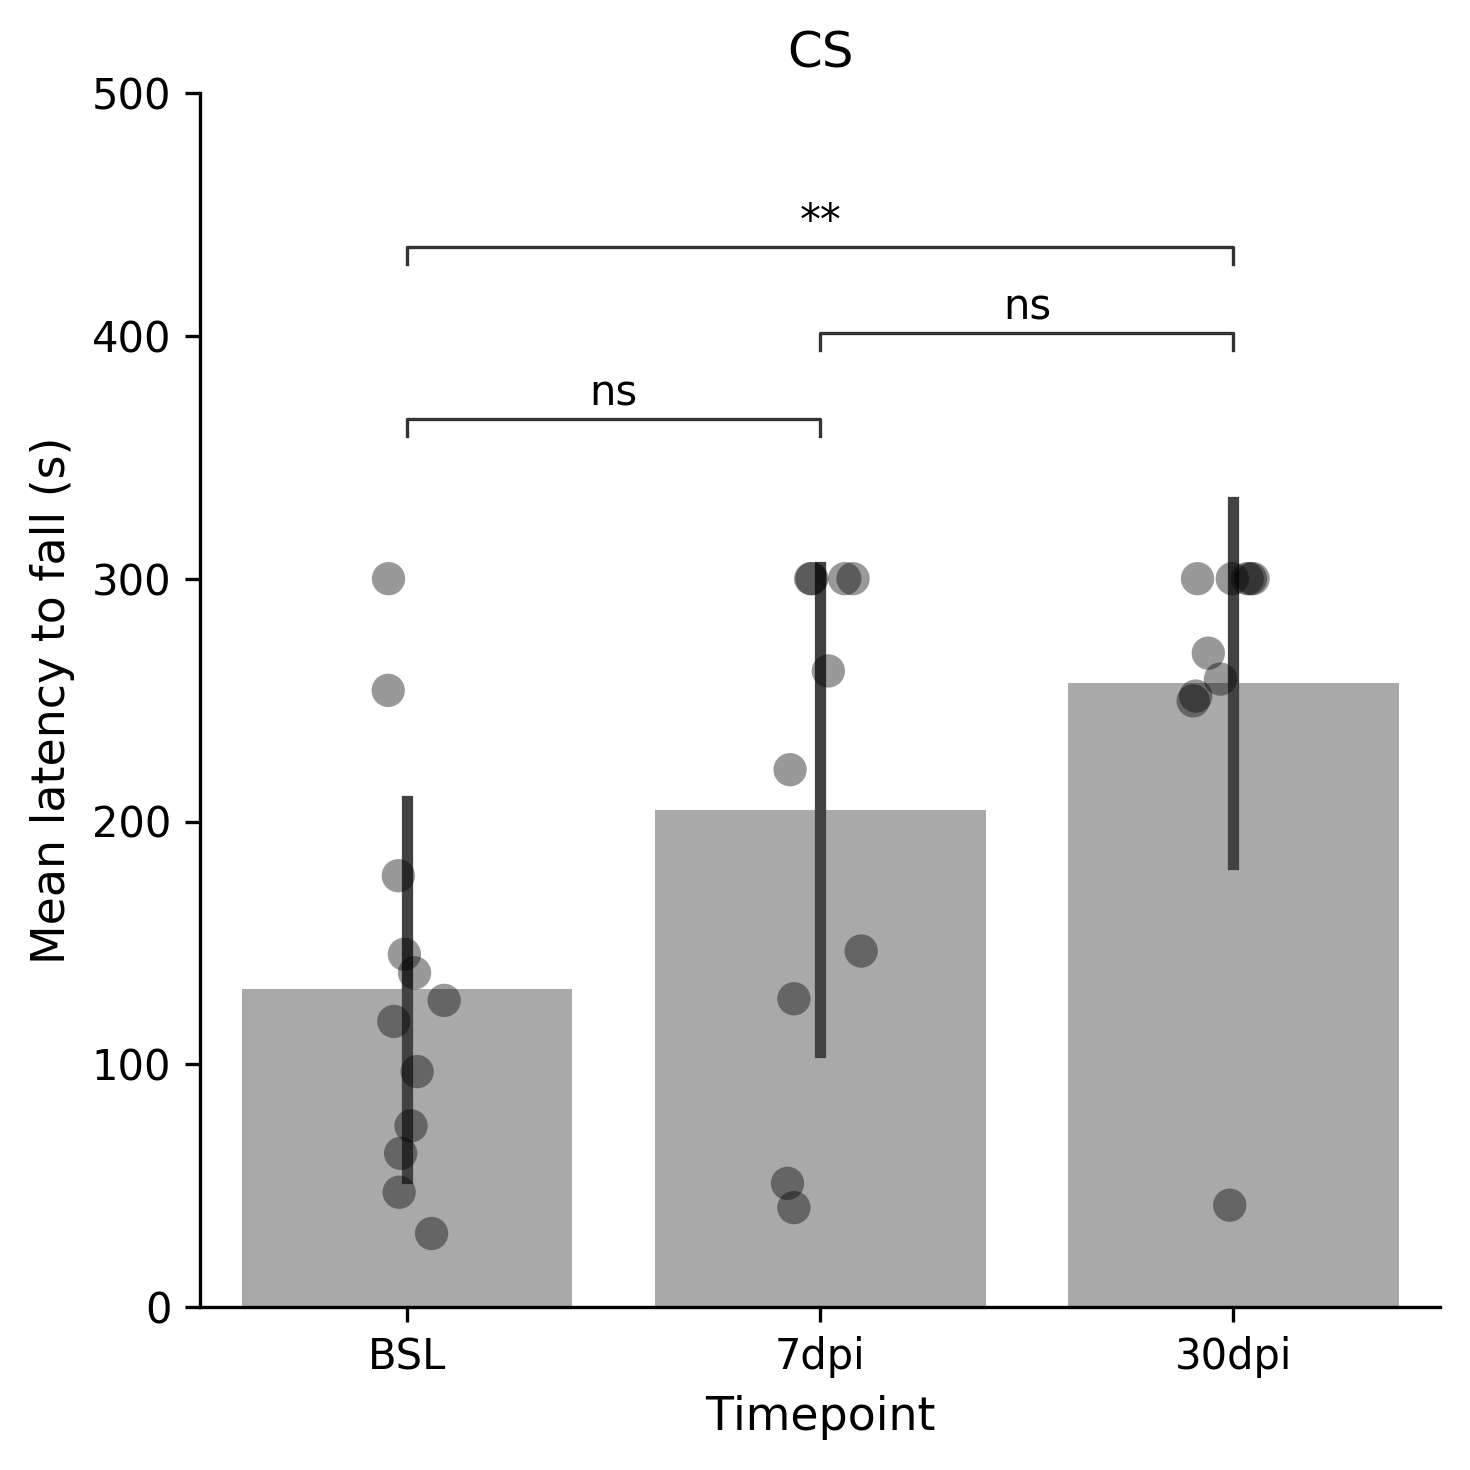

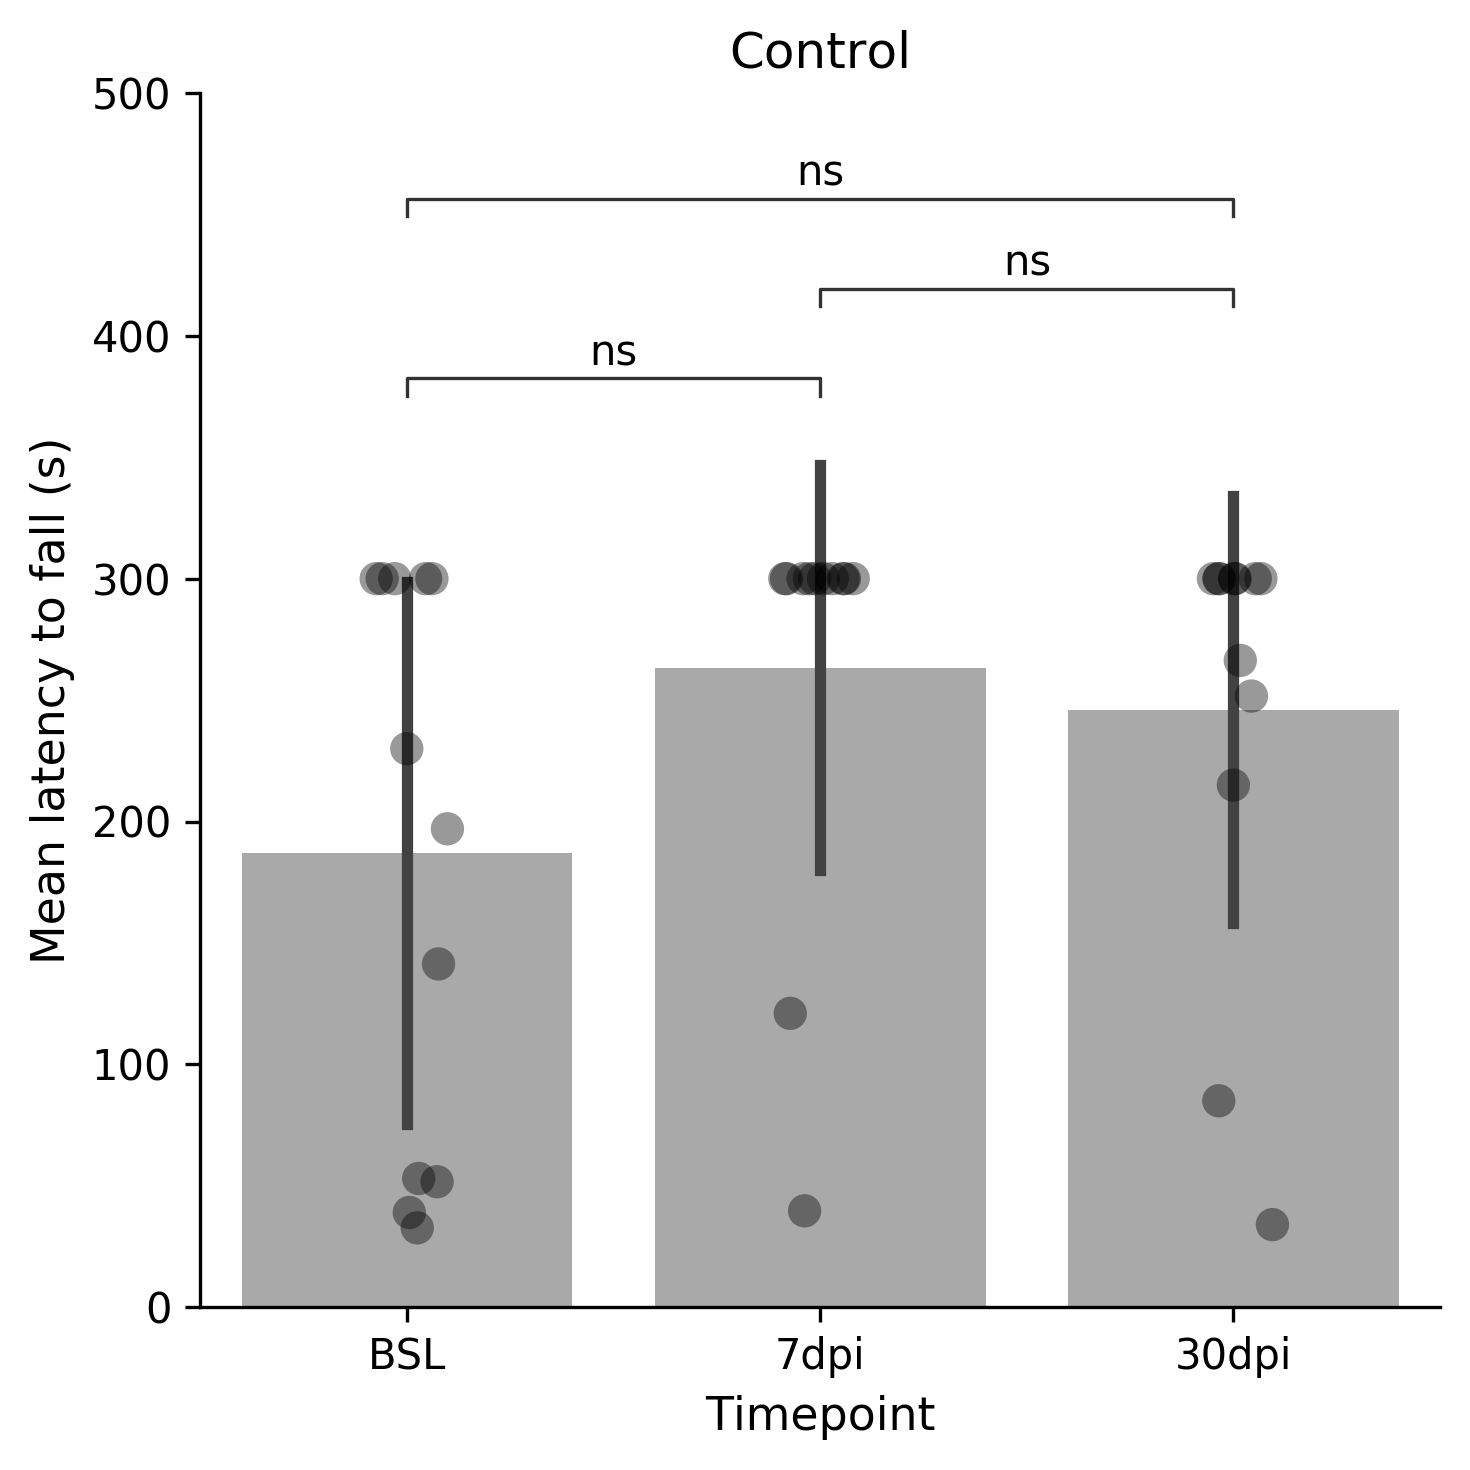

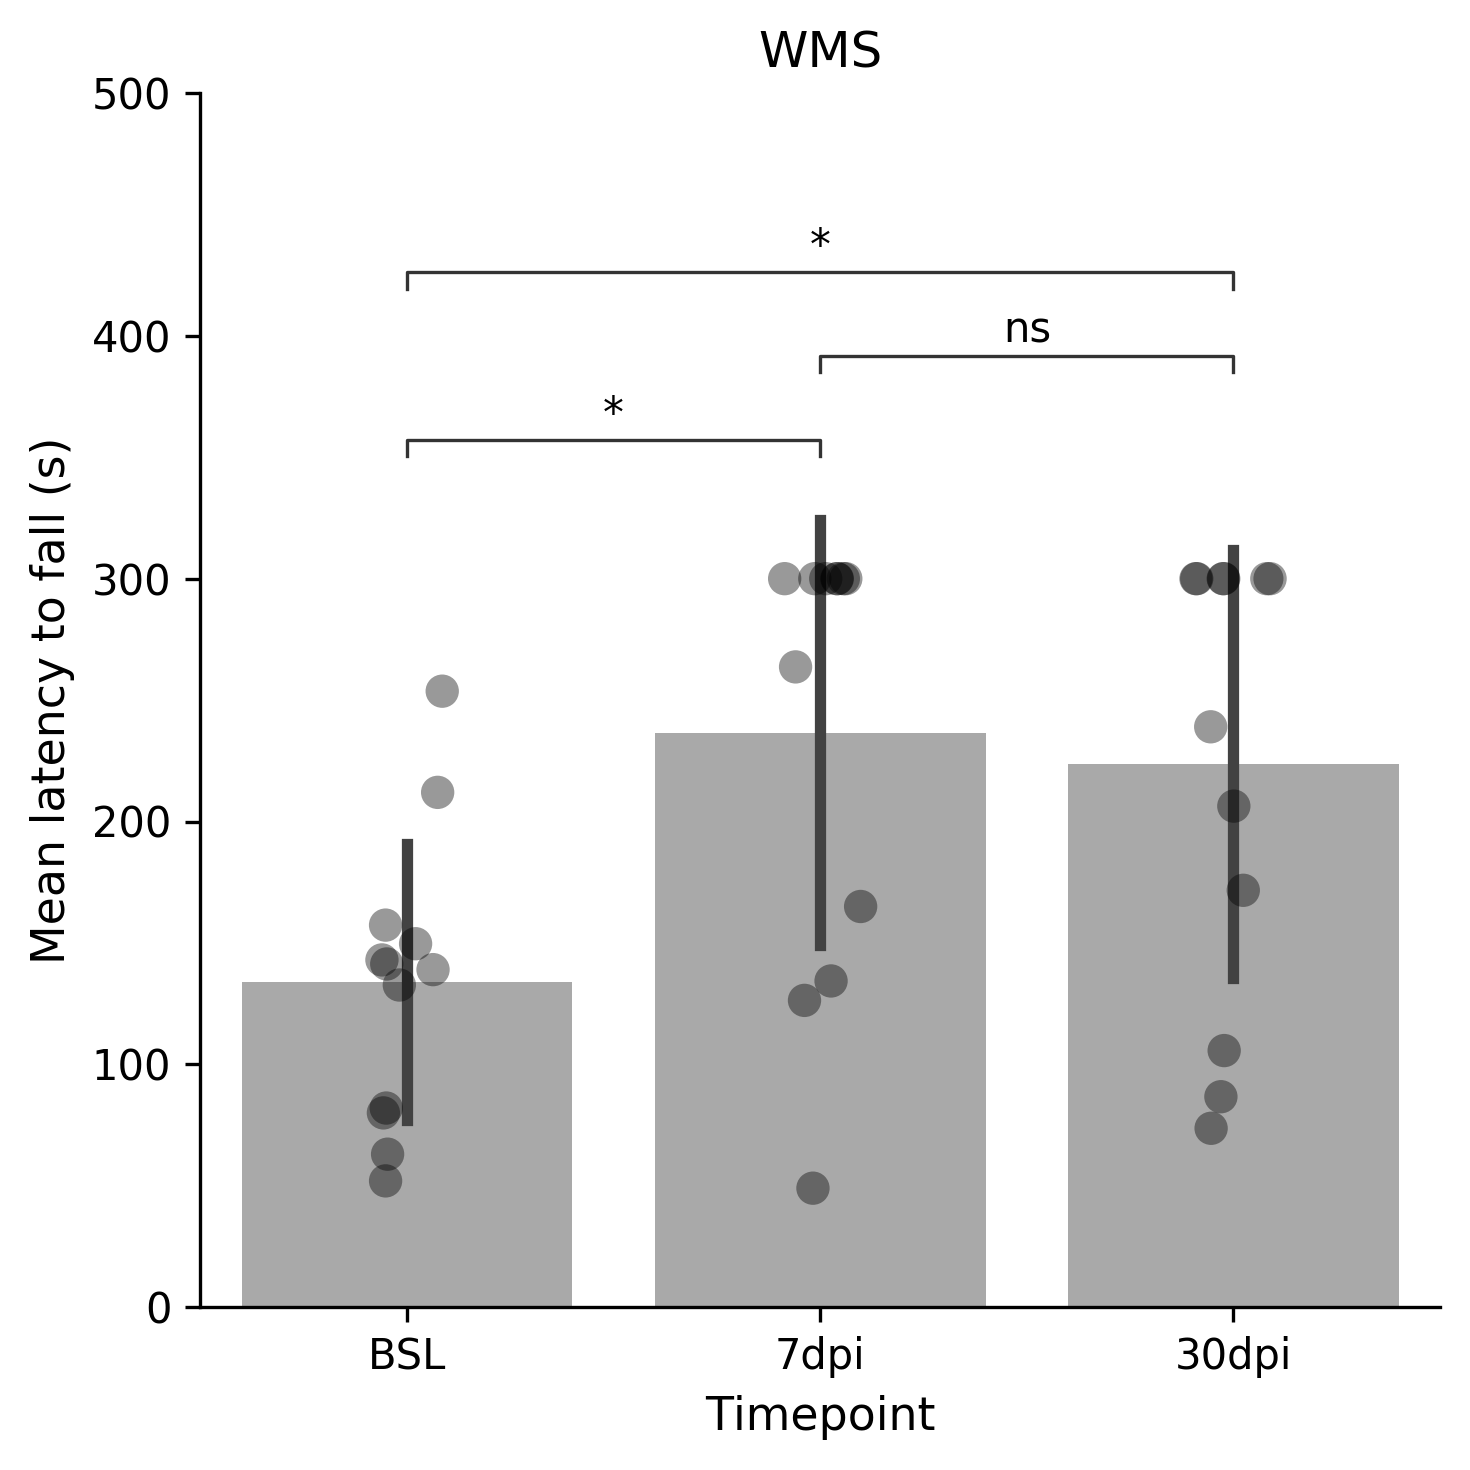

In [ ]:
for treatment, subset in df.groupby('Treatment'):
    color = 'darkgray'
    fig, ax = plt.subplots(figsize=(5, 5))
    fig.dpi = 300

    sns.barplot(
        data=subset,
        x='Timepoint',
        y='mean_latency',
        order=timepoint_order,
        color=color,
        ci='sd',
        ax=ax,
    )

    sns.stripplot(
        data=subset,
        x='Timepoint',
        y='mean_latency',
        order=timepoint_order,
        color='black',
        size=8,
        jitter=True,
        alpha=0.4,
        ax=ax,
        zorder=3,
    )

    pairs = list(combinations(timepoint_order, 2))
    annotator = Annotator(
        ax, pairs,
        data=subset,
        x='Timepoint',
        y='mean_latency',
        order=timepoint_order,
    )
    annotator.configure(
        test='Mann-Whitney',
        text_format='star',
        loc='outside',
        verbose=0,
        comparisons_correction=None,
        line_width=0.8,
        fontsize=10,
    )
    annotator.apply_and_annotate()

    ax.set_xlabel('Timepoint', fontsize=11)
    ax.set_ylim(0, 500)
    ax.set_ylabel('Mean latency to fall (s)', fontsize=11)
    ax.set_ylim(bottom=0)
    ax.set_title(treatment)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=10)
    plt.tight_layout()
    plt.savefig(SAVE_PATH/f'rotatod_results_{treatment}.pdf')
    plt.show()

In [114]:
from scipy.stats import mannwhitneyu
from itertools import combinations
import pandas as pd

results = []

for treatment, subset in df.groupby('Treatment'):
    pairs = list(combinations(timepoint_order, 2))

    for tp1, tp2 in pairs:
        # Pull the raw values for each timepoint being compared
        group1 = subset.loc[subset['Timepoint'] == tp1, 'mean_latency']
        group2 = subset.loc[subset['Timepoint'] == tp2, 'mean_latency']

        # alternative='two-sided' matches statannotations' default
        stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')

        results.append({
            'Treatment': treatment,
            'Timepoint_1': tp1,
            'Timepoint_2': tp2,
            'U_statistic': stat,
            'p_value': p_value,
        })

results_df = pd.DataFrame(results)
stats_results.append(results_df)

/tmp/ipykernel_1189/3515376724.py:16: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')


# wire hanging

**Wire Hanging** assesses forelimb grip strength and endurance — time the animal can hold onto a wire grid. Wide-format trial data is reshaped to long format and averaged per timepoint.

In [105]:
trial_cols = [c for c in wire_results.columns if c.startswith('Trial')]
id_cols = ['Mouse', 'MouseID(tick@l)', 'Treatment']

wire_long = wire_results[id_cols + trial_cols].melt(
    id_vars=id_cols,
    value_vars=trial_cols,
    var_name='trial_timepoint',
    value_name='hold_time'
)


In [106]:
trial_cols = [c for c in wire_results.columns if c.startswith('Trial')]
id_cols = ['Mouse', 'MouseID(tick@l)', 'Treatment']

wire_long = wire_results[id_cols + trial_cols].melt(
    id_vars=id_cols,
    value_vars=trial_cols,
    var_name='trial_timepoint',
    value_name='hold_time'
)

wire_long['Timepoint'] = wire_long['trial_timepoint'].str.extract(r'_(BSL|7DPI|30DPI)$')
wire_long = wire_long.dropna(subset=['Timepoint', 'hold_time'])

# Mean hold time per mouse per timepoint
wire_summary = (
    wire_long.groupby(['Mouse', 'Treatment', 'Timepoint'])['hold_time']
    .mean()
    .reset_index()
    .rename(columns={'hold_time': 'mean_hold_time'})
)

timepoint_order = ['BSL', '7DPI', '30DPI']
wire_summary['Timepoint'] = pd.Categorical(wire_summary['Timepoint'], categories=timepoint_order, ordered=True)

Skipping annotation for CS: All numbers are identical in mannwhitneyu


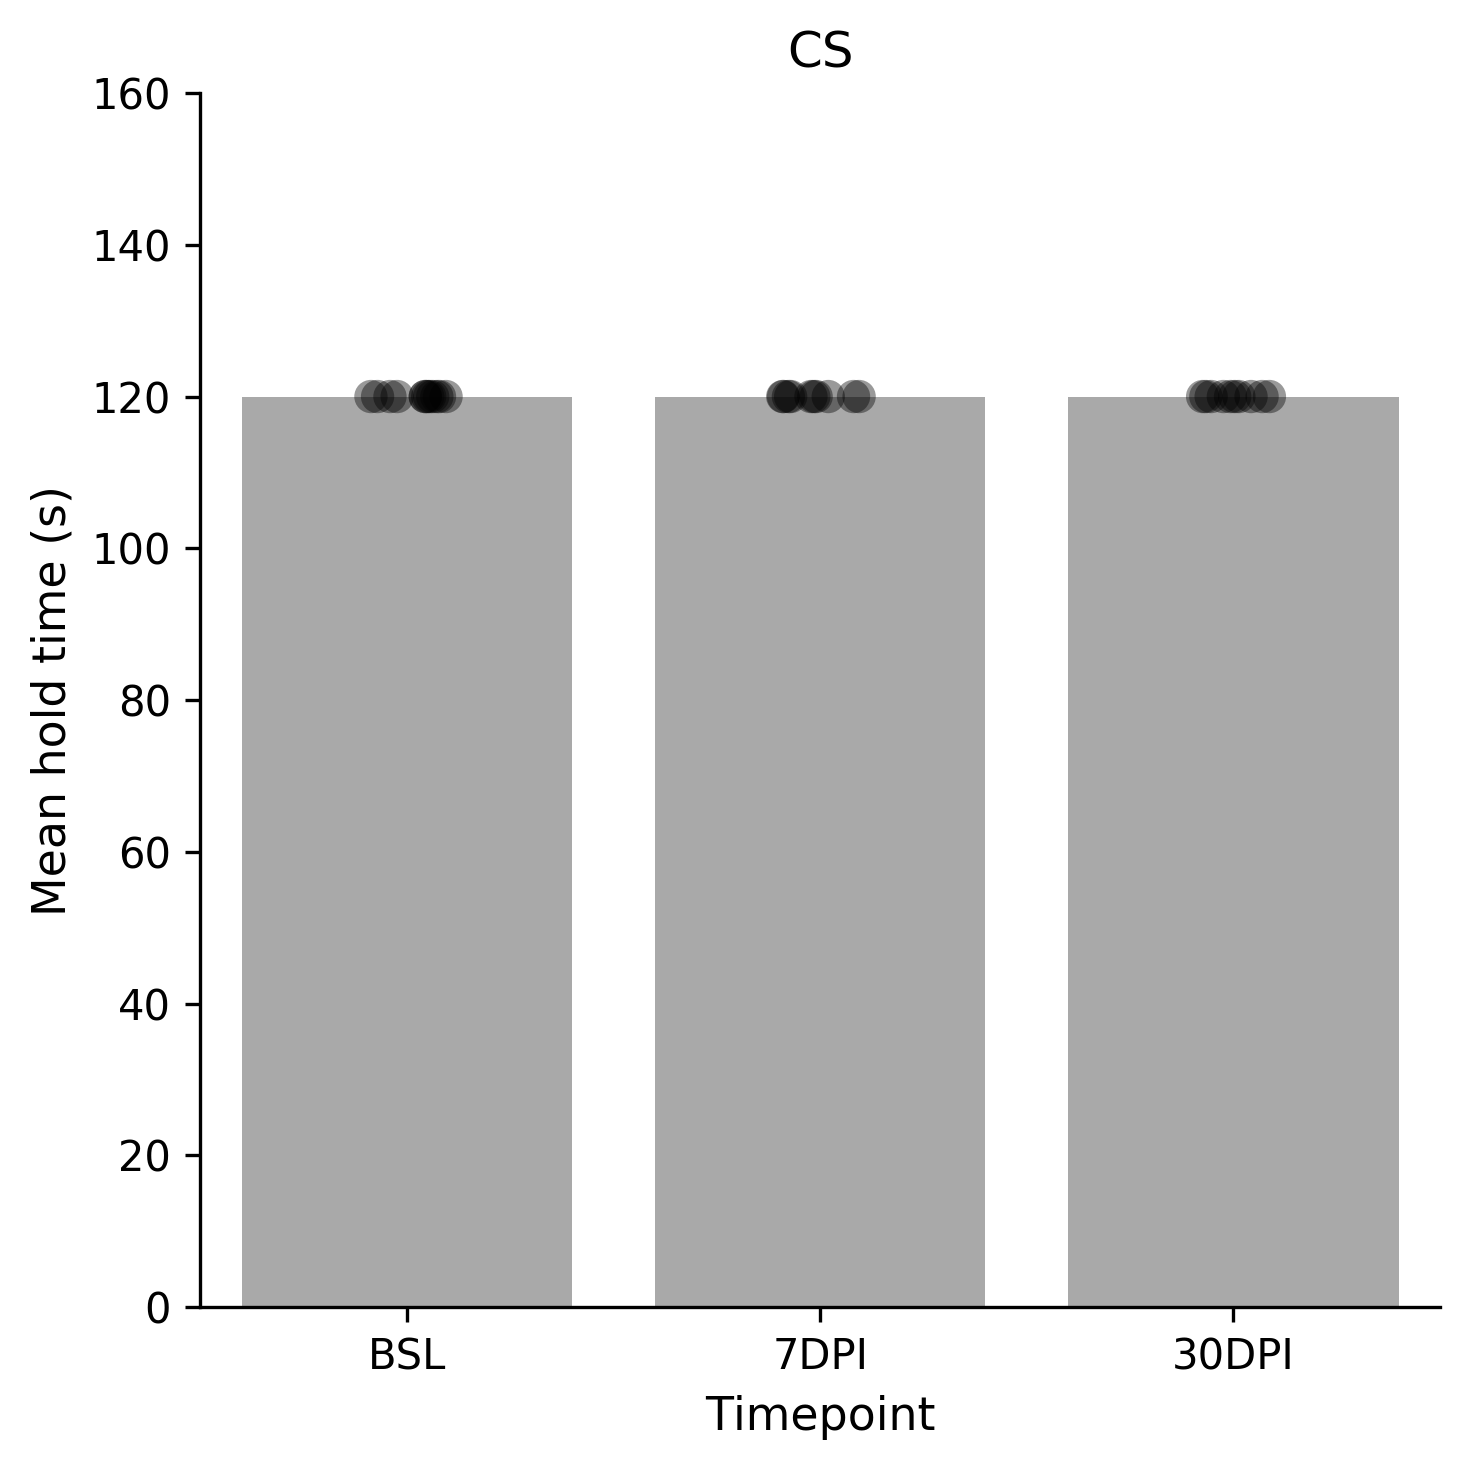

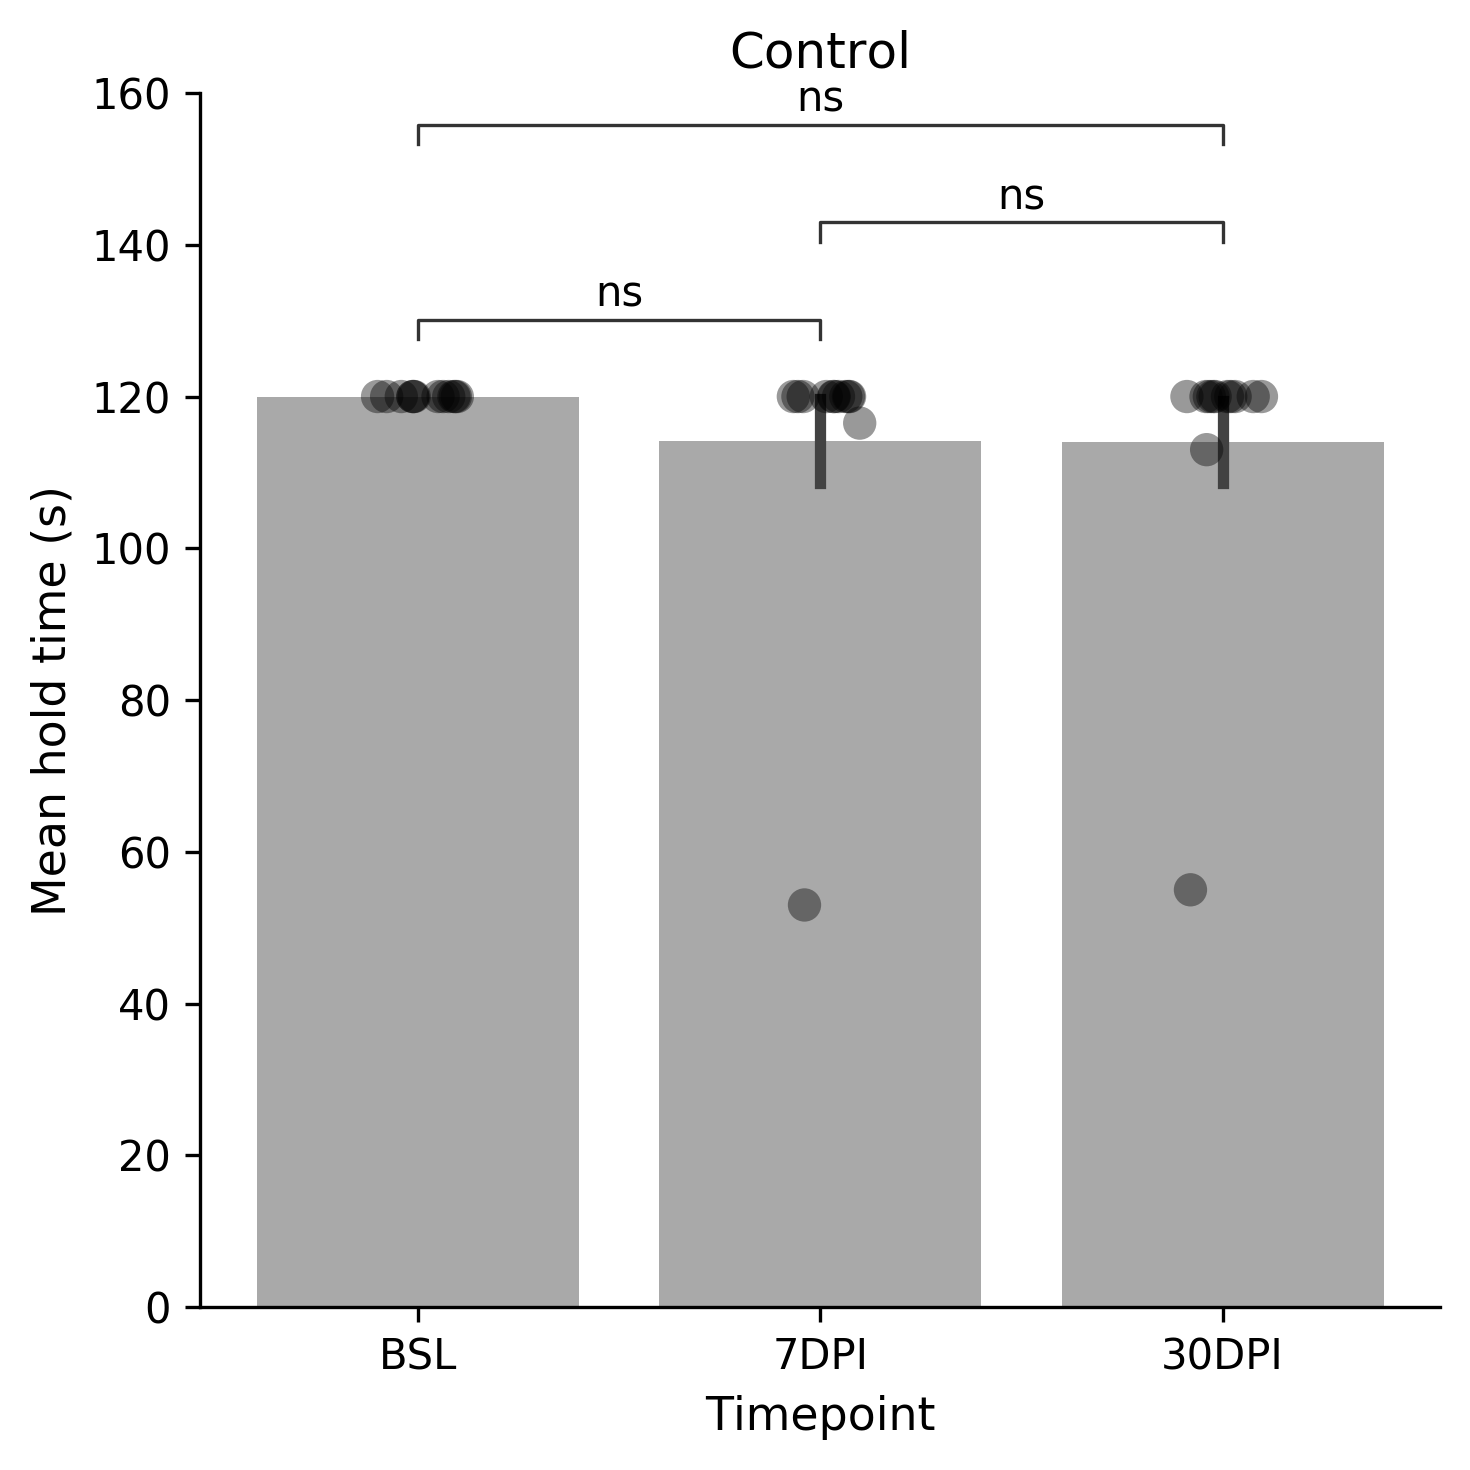

Skipping annotation for WMS: All numbers are identical in mannwhitneyu


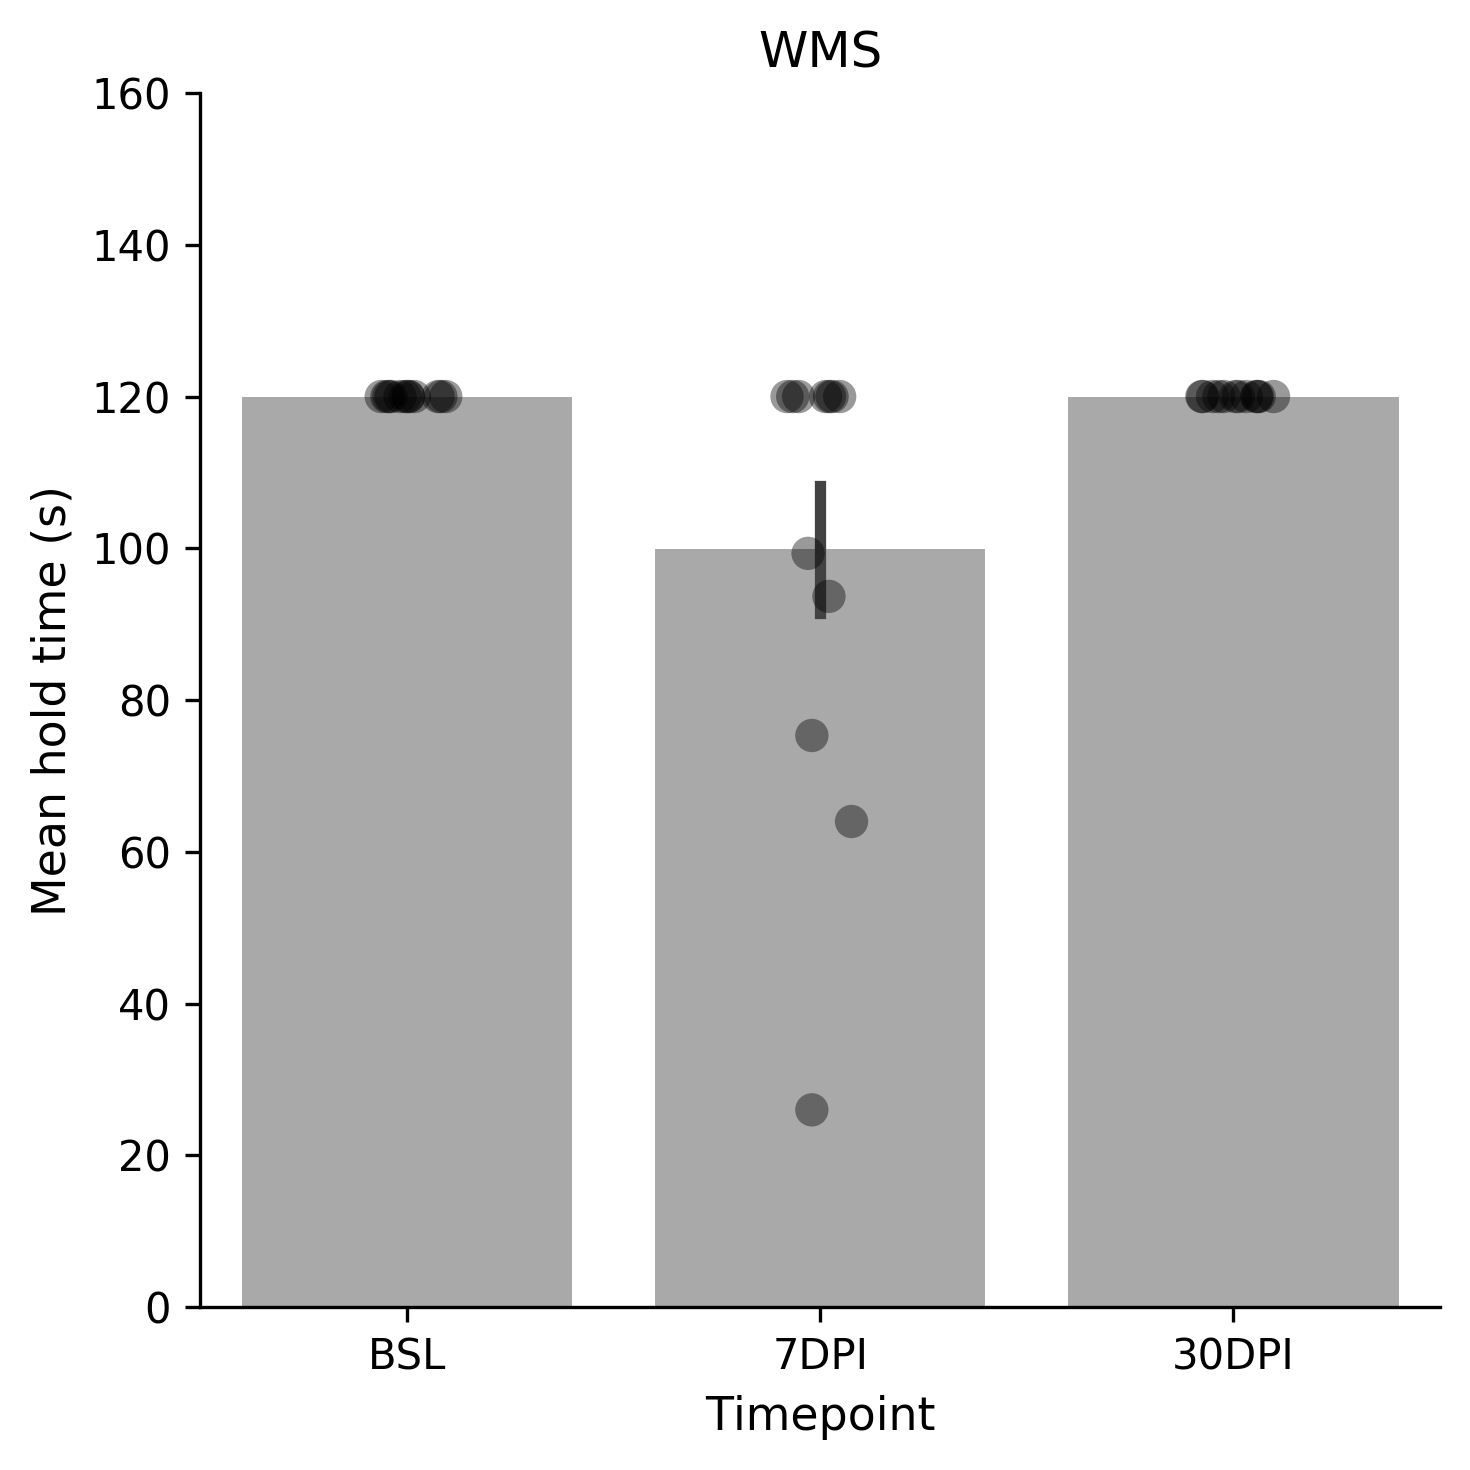

In [ ]:
for treatment, subset in wire_summary.groupby('Treatment'):
    color = 'darkgray'
    fig, ax = plt.subplots(figsize=(5, 5))
    fig.dpi = 300
    sns.barplot(
        data=subset,
        x='Timepoint',
        y='mean_hold_time',
        order=timepoint_order,
        color=color,
        ci=68,
        ax=ax,
    )
    sns.stripplot(
        data=subset,
        x='Timepoint',
        y='mean_hold_time',
        order=timepoint_order,
        color='black',
        size=8,
        jitter=True,
        alpha=0.4,
        ax=ax,
        zorder=3,
    )
    pairs = list(combinations(timepoint_order, 2))
    try:
        annotator = Annotator(
            ax, pairs,
            data=subset,
            x='Timepoint',
            y='mean_hold_time',
            order=timepoint_order,
        )
        annotator.configure(
            test='Mann-Whitney',
            text_format='star',
            loc='inside',
            verbose=0,
            comparisons_correction=None,
            line_width=0.8,
            fontsize=10,
        )
        annotator.apply_and_annotate()
    except ValueError as e:
        print(f"Skipping annotation for {treatment}: {e}")
    ax.set_title(treatment)
    ax.set_xlabel('Timepoint', fontsize=11)
    ax.set_ylabel('Mean hold time (s)', fontsize=11)
    ax.set_ylim(0, 160)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=10)
    plt.tight_layout()
    plt.savefig(SAVE_PATH/f'Wire_Hanging_Results_{treatment}.pdf')
    plt.show()

In [109]:
from scipy.stats import mannwhitneyu
from itertools import combinations
import pandas as pd

wire_results = []

for treatment, subset in df.groupby('Treatment'):
    pairs = list(combinations(timepoint_order, 2))

    for tp1, tp2 in pairs:
        # Pull the raw values for each timepoint being compared
        group1 = subset.loc[subset['Timepoint'] == tp1, 'mean_latency']
        group2 = subset.loc[subset['Timepoint'] == tp2, 'mean_latency']

        # alternative='two-sided' matches statannotations' default
        stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')

        wire_results.append({
            'Treatment': treatment,
            'Timepoint_1': tp1,
            'Timepoint_2': tp2,
            'U_statistic': stat,
            'p_value': p_value,
        })

wire_results_df = pd.DataFrame(wire_results)
stats_results.append(wire_results_df)

/tmp/ipykernel_1189/3697769551.py:29: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')


# gridwalk

**Gridwalk** quantifies motor coordination via foot fault rate on a wire grid — reported as the relative forelimb fault percentage (RFF%). Group labels are parsed from the `Group` column; '21dpi' is harmonized to '30dpi'.

In [ ]:
gridwalk[['Treatment', 'Timepoint']] = gridwalk['Group'].str.rsplit('_', n=1, expand=True)

gridwalk['Timepoint'] = gridwalk['Timepoint'].replace({'21dpi': '30dpi'}).astype(str)
timepoint_order = ['Baseline', '7dpi', '30dpi']

In [ ]:
gridwalk['Timepoint'].unique()

array(['Baseline', '7dpi', '30dpi'], dtype=object)

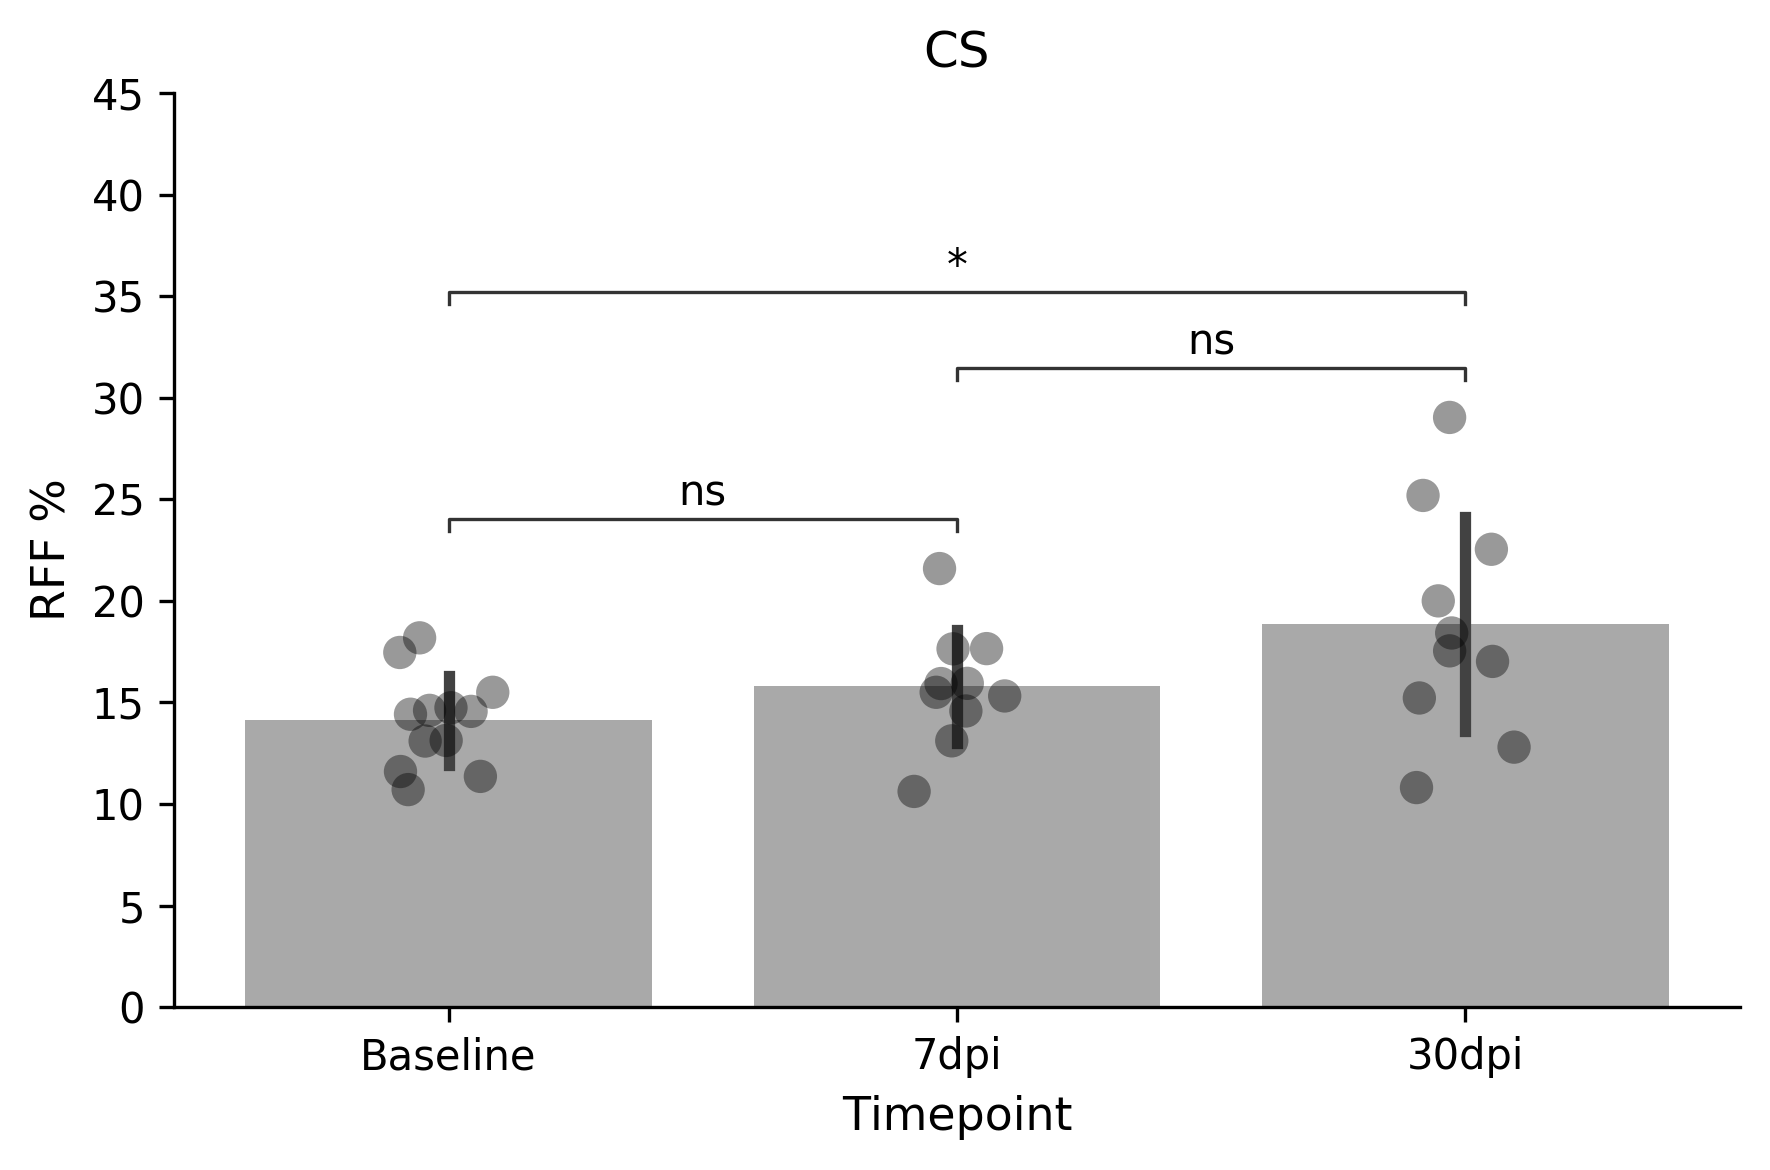

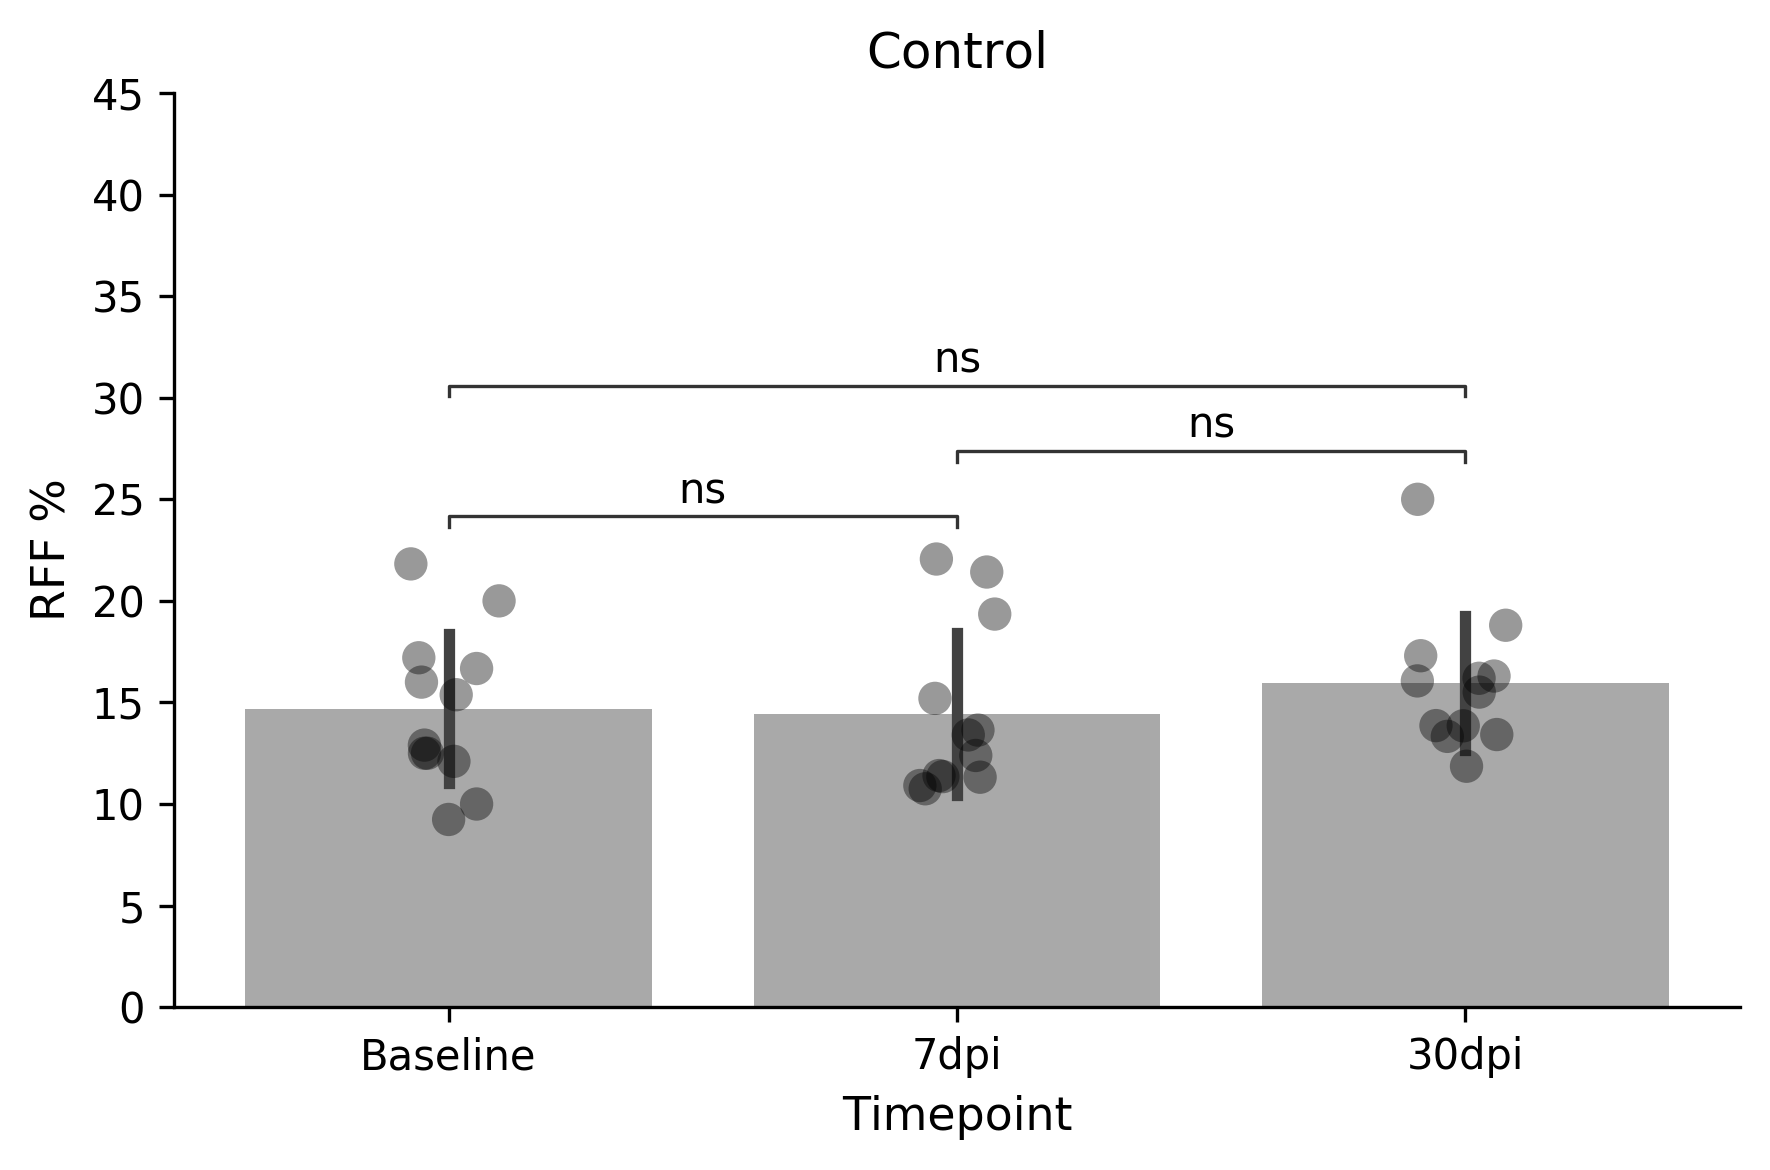

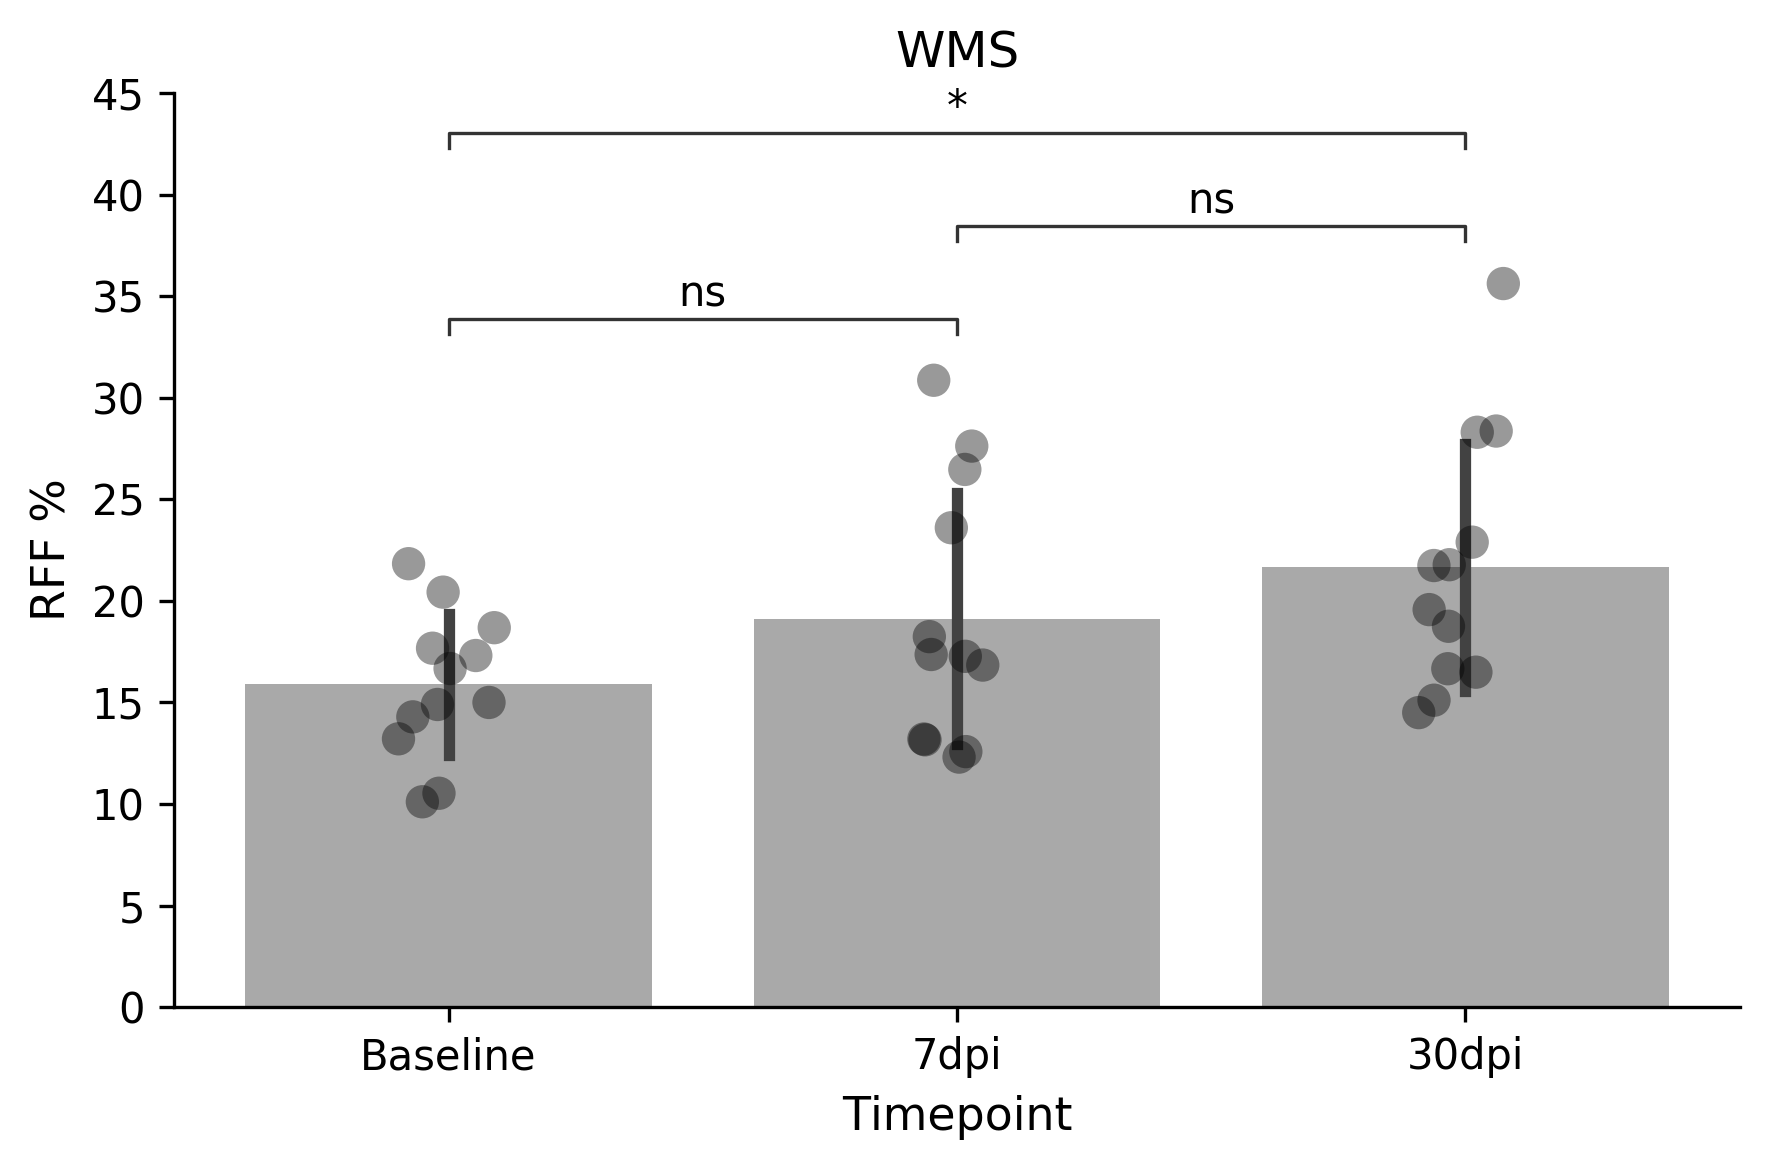

In [ ]:
for treatment, subset in gridwalk.groupby('Treatment'):
    subset = subset.copy()
    present = subset['Timepoint'].unique().tolist()
    pairs = [p for p in combinations(timepoint_order, 2) if p[0] in present and p[1] in present]

    fig, ax = plt.subplots()
    fig.dpi = 300

    sns.barplot(
        data=subset,
        x='Timepoint',
        y='RFF Percentage',
        order=timepoint_order,
        color='darkgray',
        ci='sd',
        ax=ax,
    )
    sns.stripplot(
        data=subset,
        x='Timepoint',
        y='RFF Percentage',
        order=timepoint_order,
        color='black',
        size=8,
        jitter=True,
        alpha=0.4,
        ax=ax,
        zorder=3,
    )

    try:
        annotator = Annotator(
            ax, pairs,
            data=subset,
            x='Timepoint',
            y='RFF Percentage',
            order=timepoint_order,
        )
        annotator.configure(
            test='Mann-Whitney',
            text_format='star',
            loc='inside',
            verbose=0,
            comparisons_correction=None,
            line_width=0.8,
            fontsize=10,
        )
        annotator.apply_and_annotate()
    except ValueError as e:
        print(f"Skipping annotation for {treatment}: {e}")

    ax.set_title(treatment)
    ax.set_xlabel('Timepoint', fontsize=11)
    ax.set_ylabel('RFF %', fontsize=11)
    ax.set_ylim(0, 45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=10)
    plt.tight_layout()
    plt.savefig(SAVE_PATH / f'Gridwalk_Results_{treatment}.pdf')
    plt.show()

# ymaze

**Y-Maze** tests spatial working memory via spontaneous alternation — the percentage of unique arm entries out of total entries. A dashed chance line at 50% is included for reference.

In [ ]:
timepoint_order = ['BSL', '7DPI', '30DPI']
ymaze['Timepoint'] = ymaze['Timepoint'].astype(str)

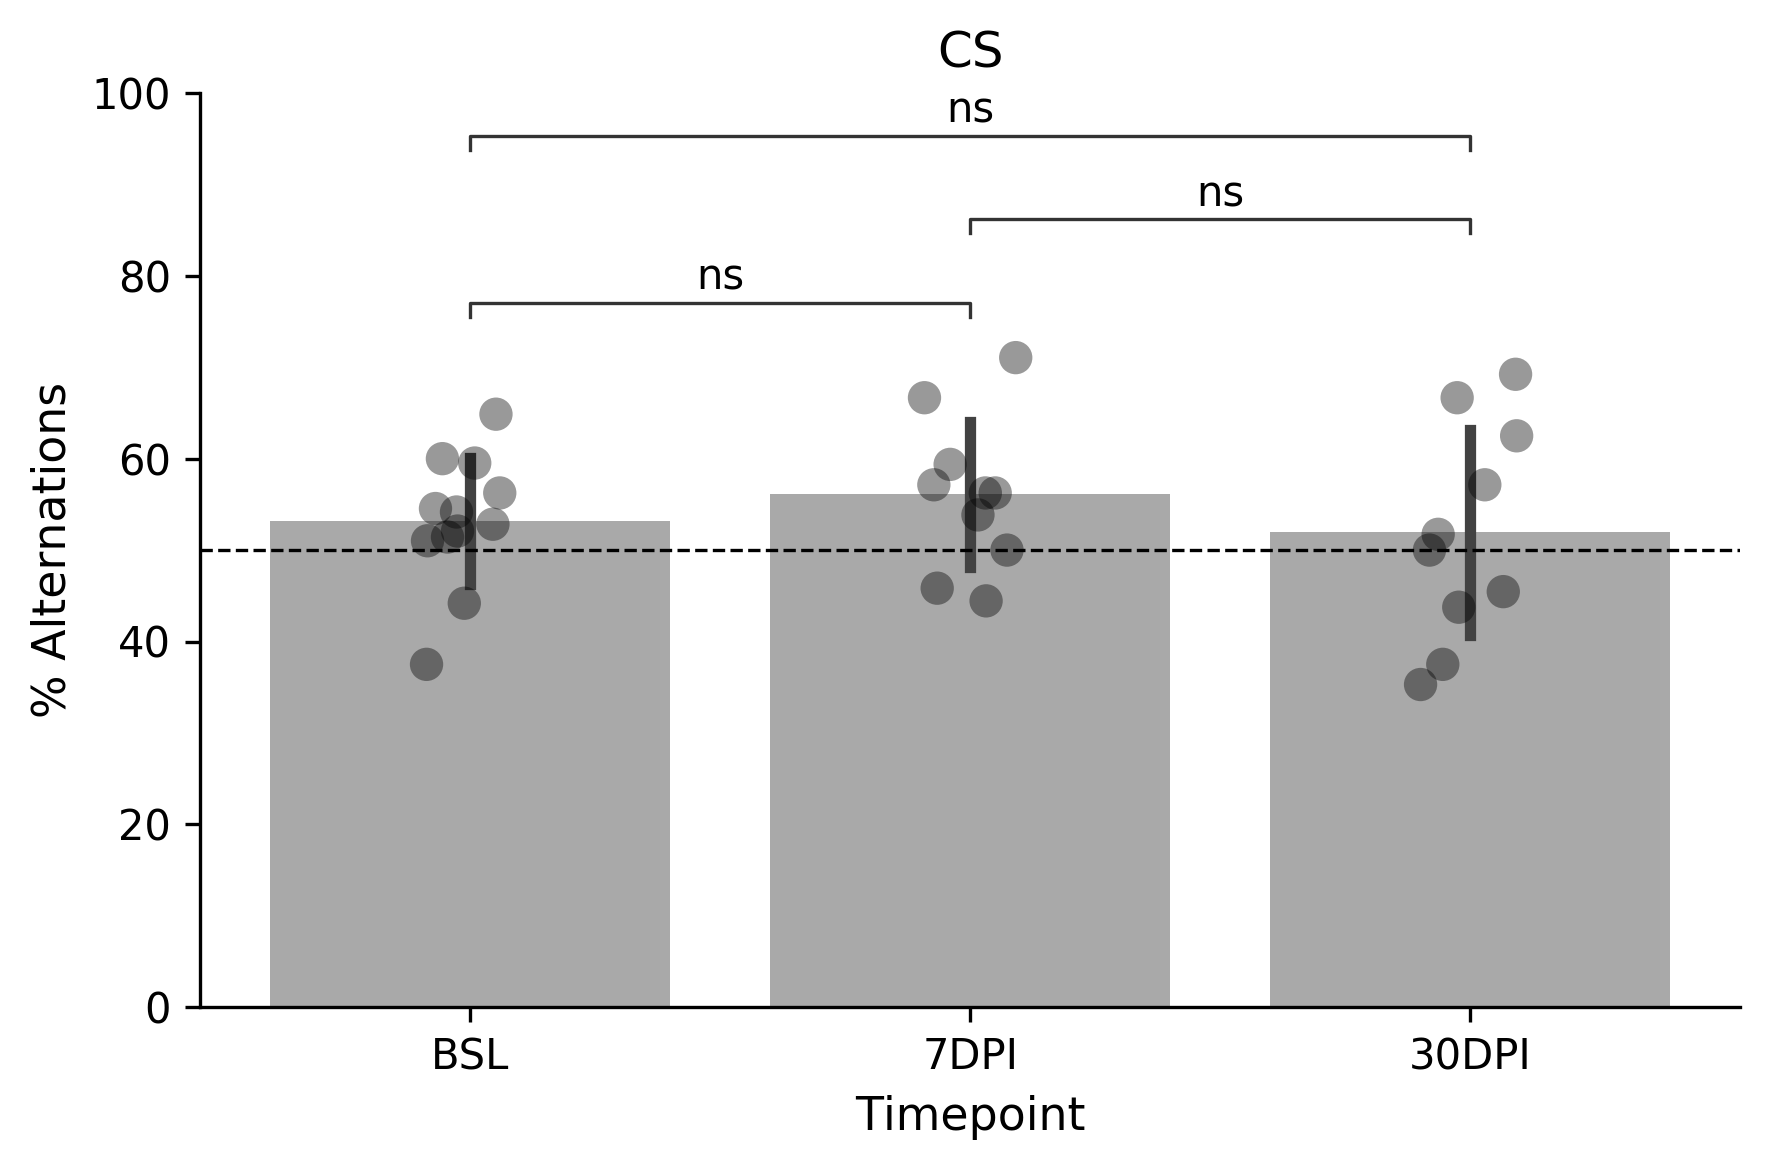

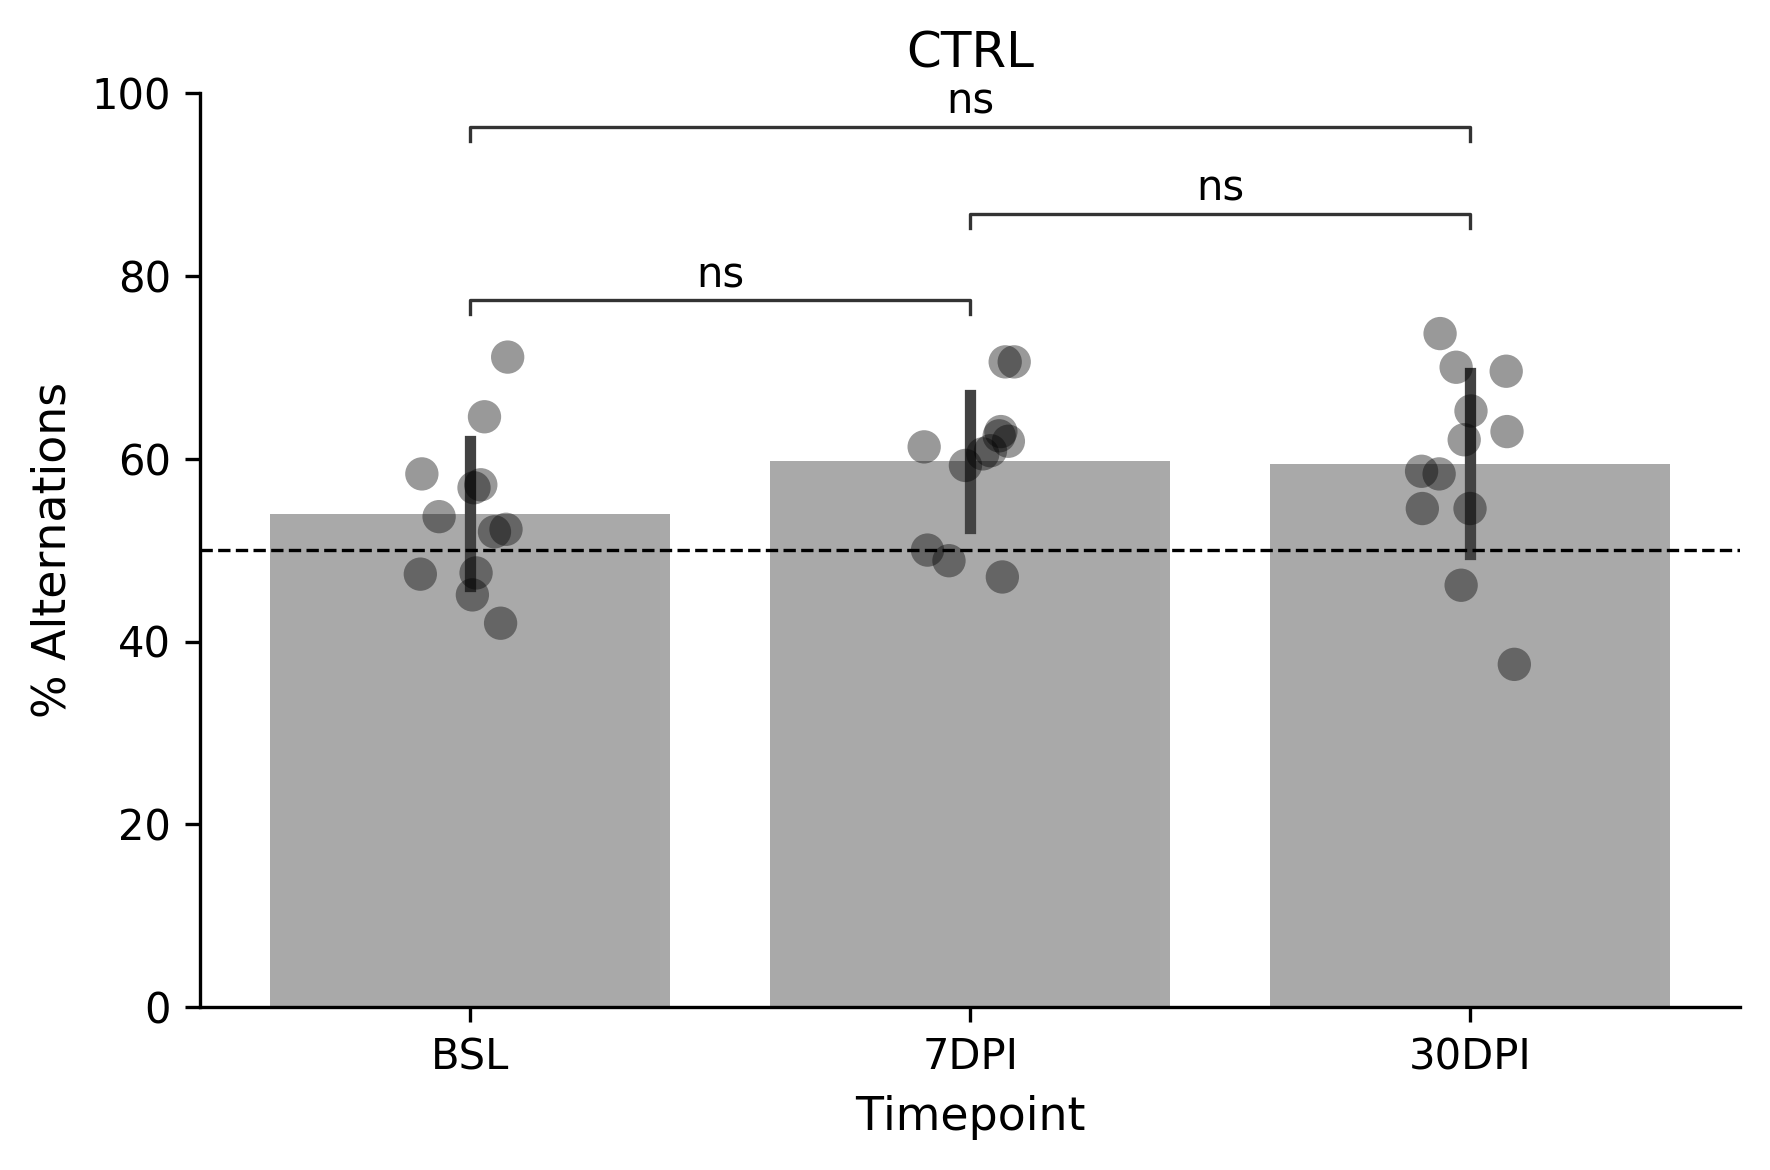

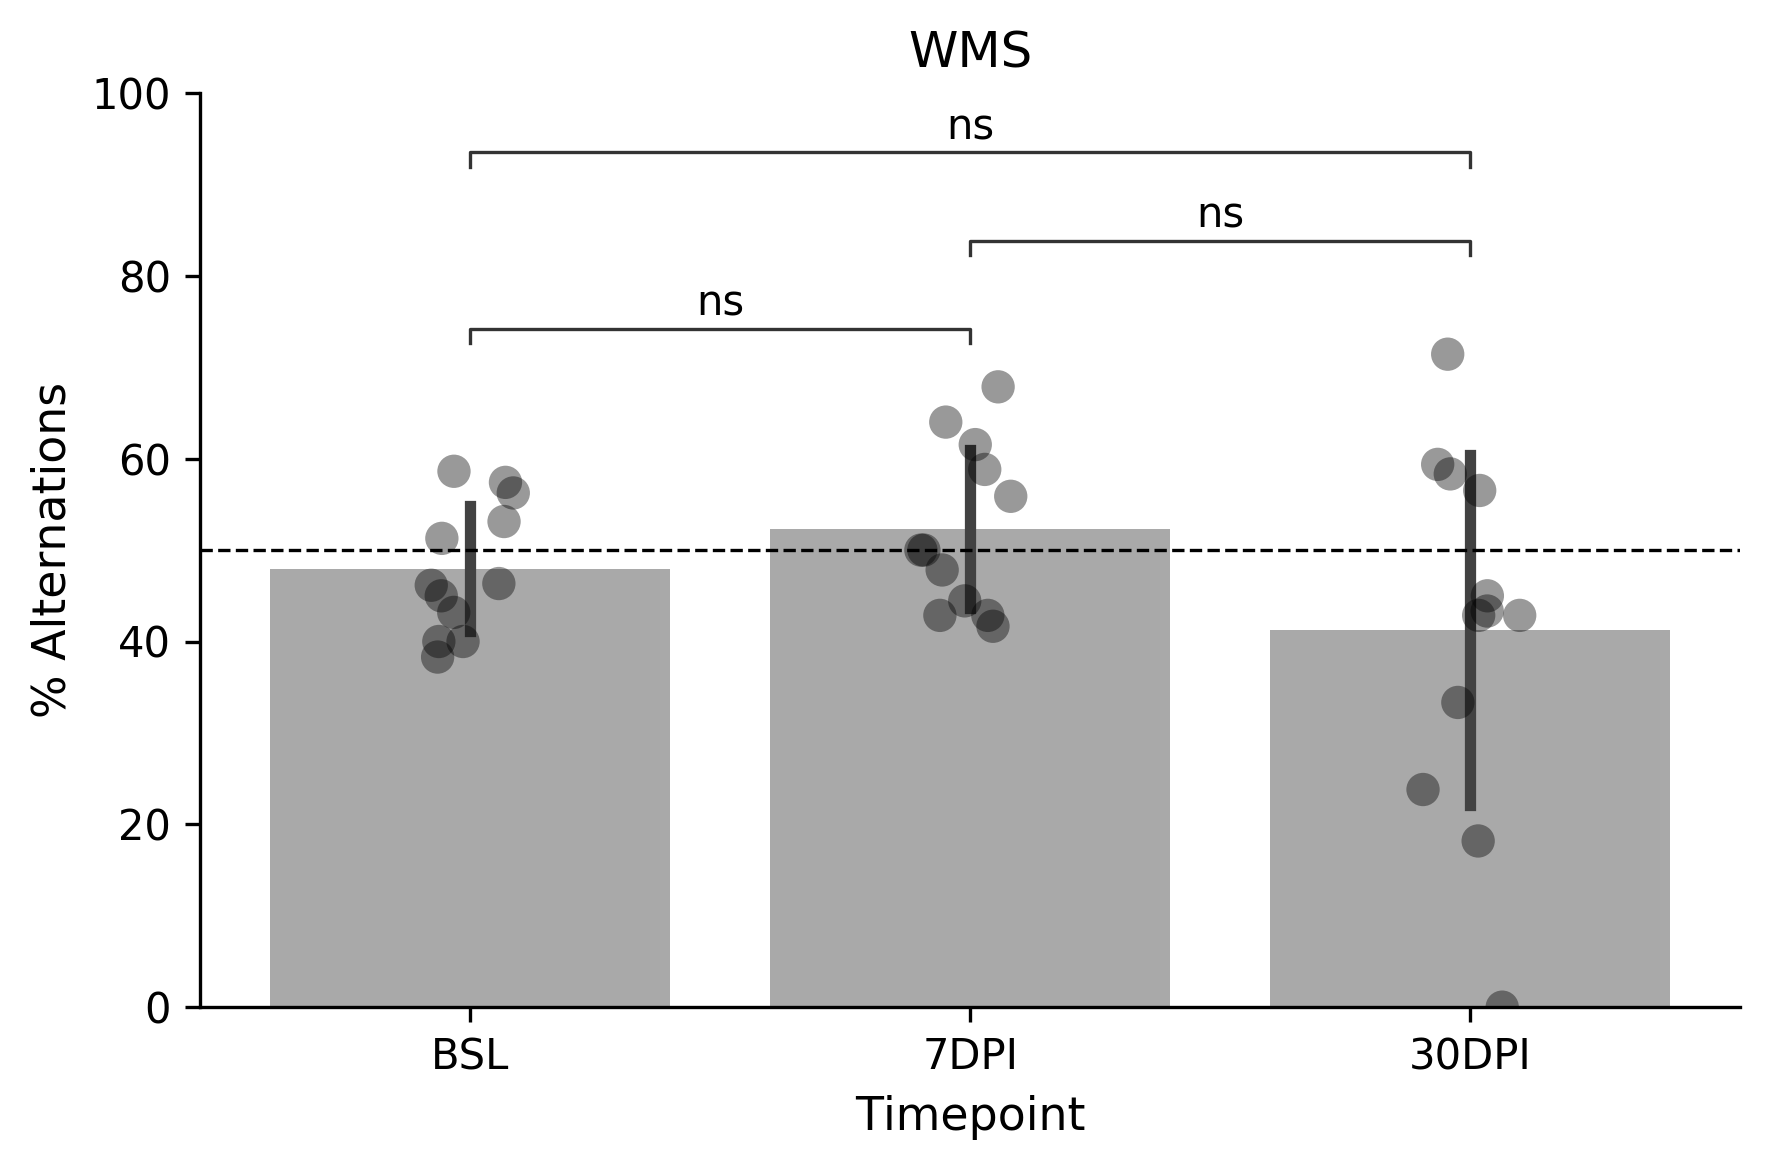

In [ ]:
for treatment, subset in ymaze.groupby('Group'):
    subset = subset.copy()
    present = subset['Timepoint'].unique().tolist()
    pairs = [p for p in combinations(timepoint_order, 2) if p[0] in present and p[1] in present]

    fig, ax = plt.subplots()
    fig.dpi = 300

    sns.barplot(
        data=subset,
        x='Timepoint',
        y='% Alternations',
        order=timepoint_order,
        color='darkgray',
        ci='sd',
        ax=ax,
    )
    sns.stripplot(
        data=subset,
        x='Timepoint',
        y='% Alternations',
        order=timepoint_order,
        color='black',
        size=8,
        jitter=True,
        alpha=0.4,
        ax=ax,
        zorder=3,
    )

    try:
        annotator = Annotator(
            ax, pairs,
            data=subset,
            x='Timepoint',
            y='% Alternations',
            order=timepoint_order,
        )
        annotator.configure(
            test='Mann-Whitney',
            text_format='star',
            loc='inside',
            verbose=0,
            comparisons_correction=None,
            line_width=0.8,
            fontsize=10,
        )
        annotator.apply_and_annotate()
    except ValueError as e:
        print(f"Skipping annotation for {treatment}: {e}")

    # chance level reference line
    ax.axhline(50, color='black', linestyle='--', linewidth=0.8, label='Chance (50%)')

    ax.set_title(treatment)
    ax.set_xlabel('Timepoint', fontsize=11)
    ax.set_ylabel('% Alternations', fontsize=11)
    ax.set_ylim(0, 100)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=10)
    plt.tight_layout()
    plt.savefig(SAVE_PATH / f'YMaze_Results_{treatment}.pdf')
    plt.show()

# nort

**Novel Object Recognition Test (NORT)** measures recognition memory via the discrimination index (time with novel object − time with familiar object) / total exploration time. Visualized as a violin plot.

In [ ]:
timepoint_order = ['BSL', '30DPI']
nort['timepoint'] = nort['timepoint'].astype(str)

In [ ]:
nort.columns

Index(['mouse_id', 'timepoint', 'treatment', 'video_stem', 'n_frames',
       'time_novel', 'time_familiar', 'total_time', 'difference_score',
       'discrimination_index', 'preference_ratio'],
      dtype='object')

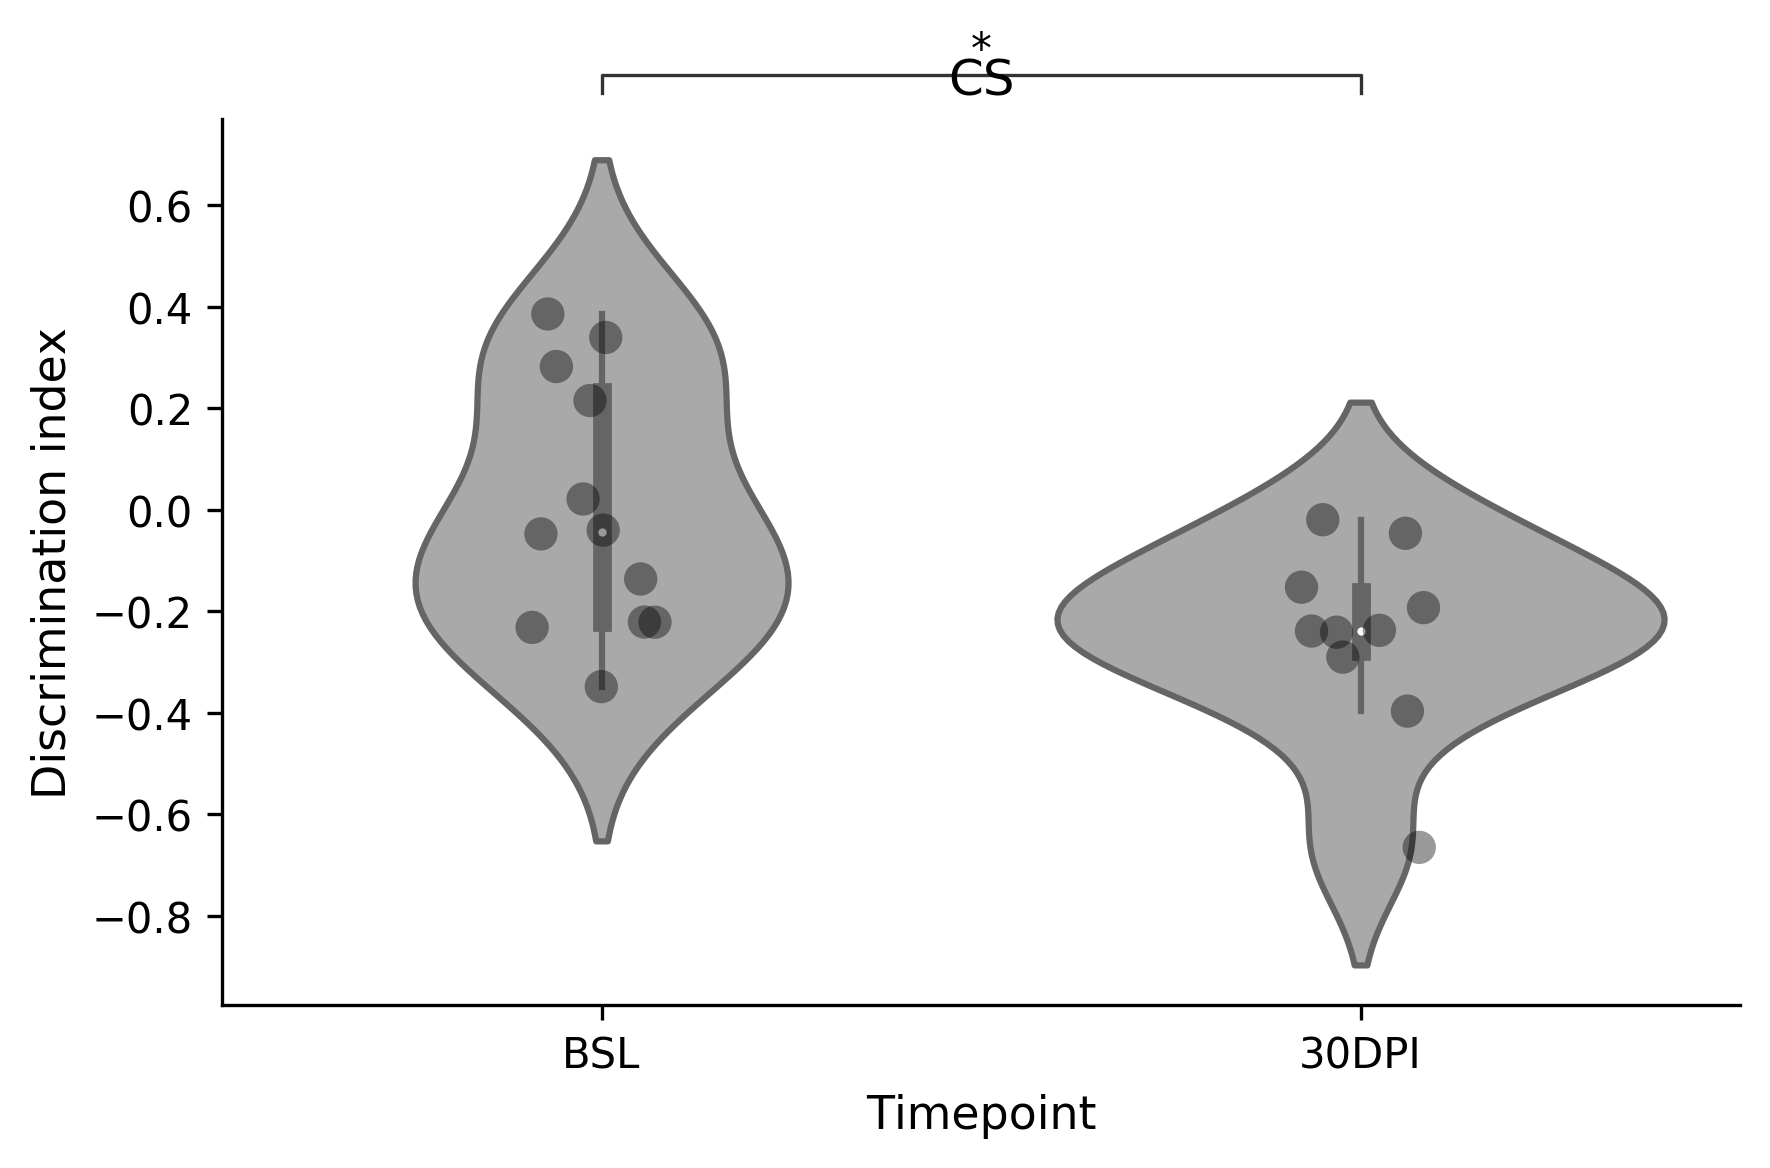

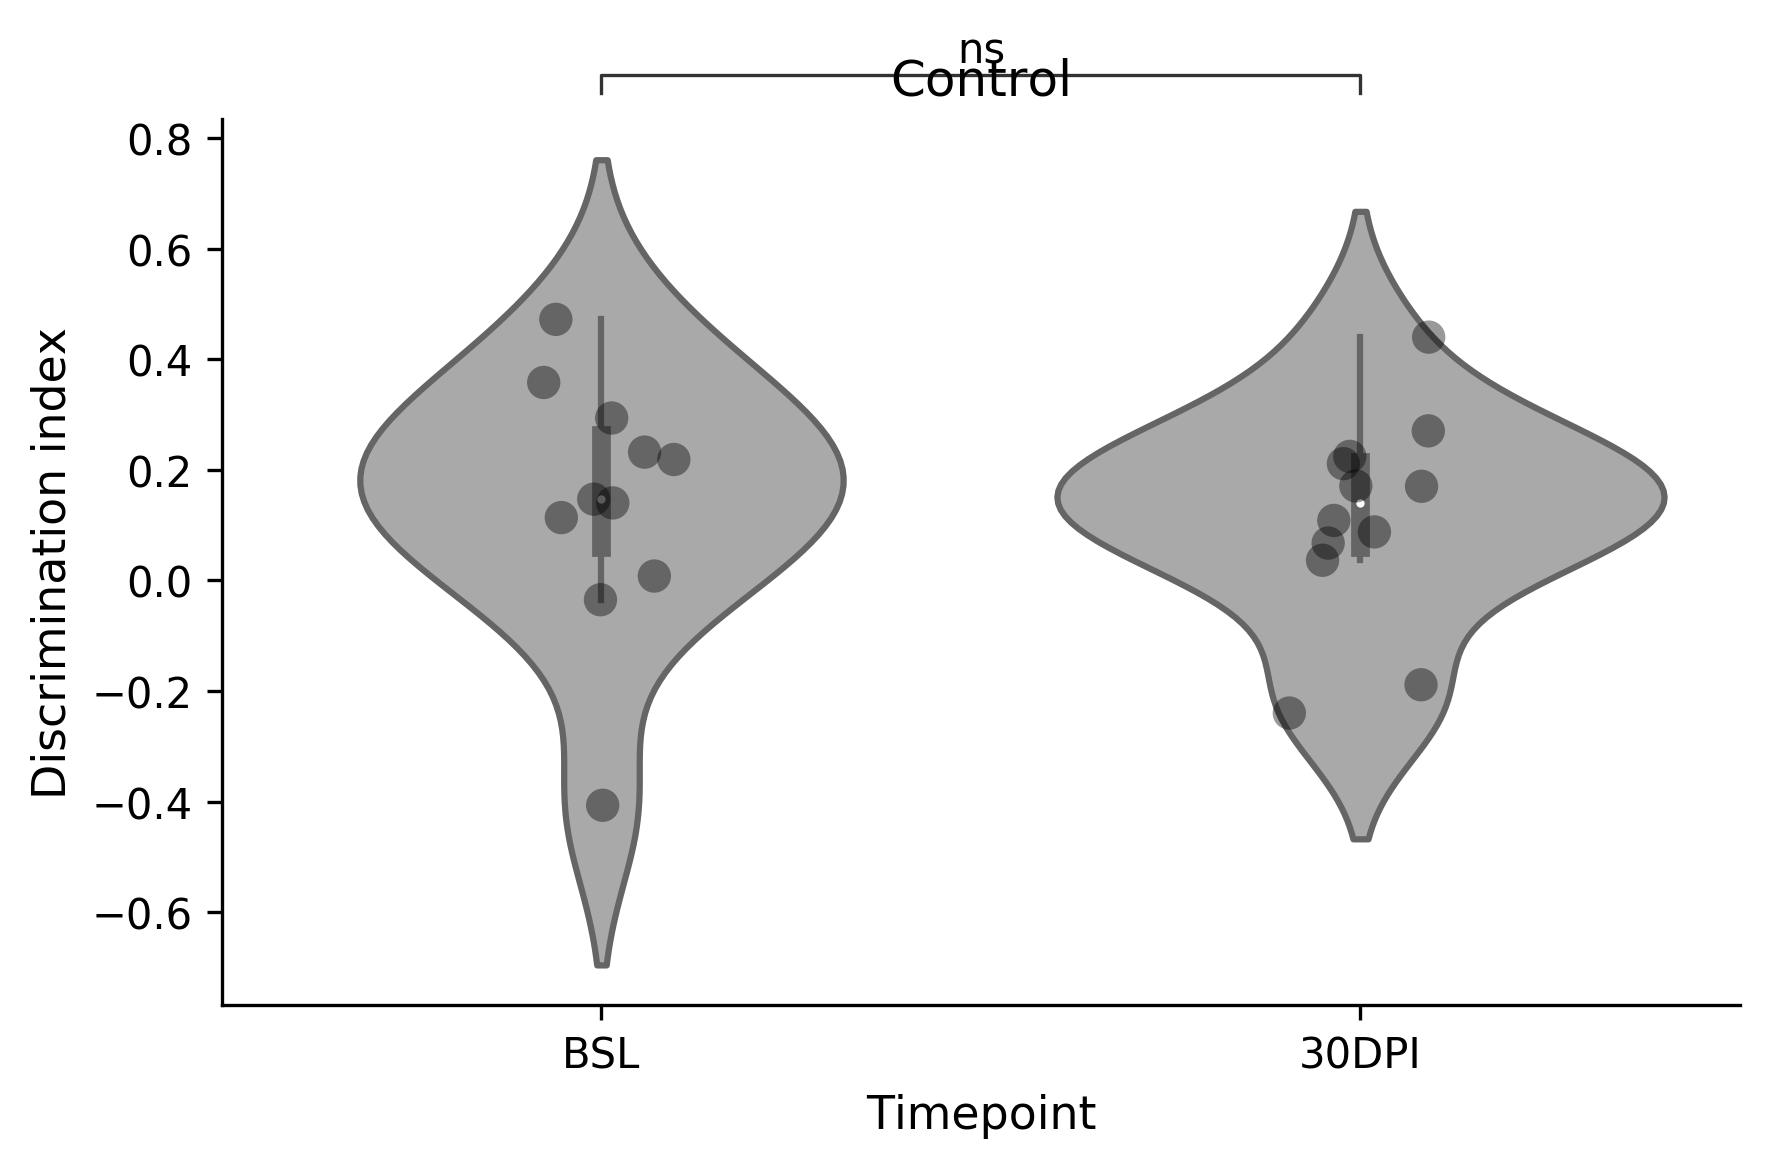

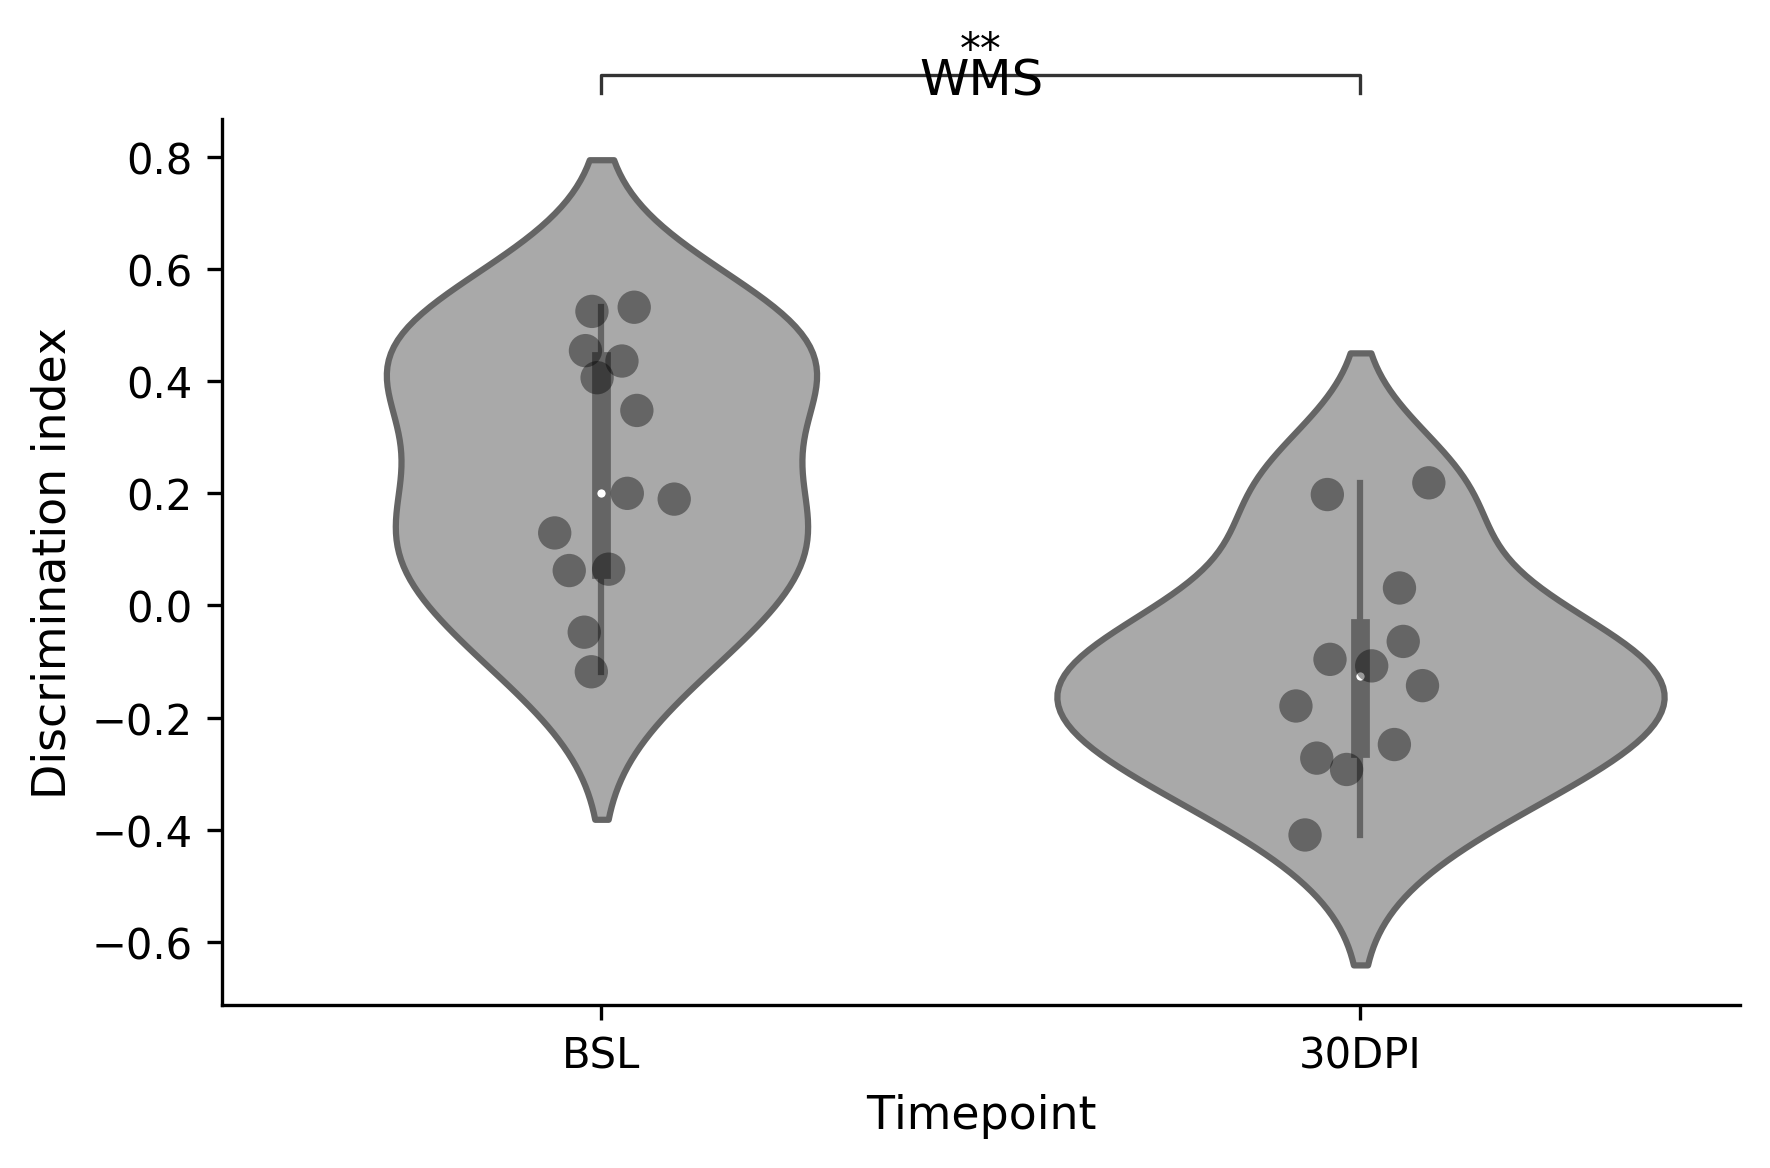

In [ ]:
for treatment, subset in nort.groupby('treatment'):
    subset = subset.copy()
    present = subset['timepoint'].unique().tolist()
    pairs = [p for p in combinations(timepoint_order, 2) if p[0] in present and p[1] in present]


    fig, ax = plt.subplots()
    fig.dpi = 300

    sns.violinplot(
        data=subset,
        x='timepoint',
        y='discrimination_index',
        order=timepoint_order,
        color='darkgray',
        ci='sd',
        ax=ax,
    )
    sns.stripplot(
        data=subset,
        x='timepoint',
        y='discrimination_index',
        order=timepoint_order,
        color='black',
        size=8,
        jitter=True,
        alpha=0.4,
        ax=ax,
        zorder=3,
    )

    try:
        annotator = Annotator(
            ax, pairs,
            data=subset,
            x='timepoint',
            y='discrimination_index',
            order=timepoint_order,
        )
        annotator.configure(
            test='Mann-Whitney',
            text_format='star',
            loc='outside',
            verbose=0,
            comparisons_correction=None,
            line_width=0.8,
            fontsize=10,
        )
        annotator.apply_and_annotate()
    except ValueError as e:
        print(f"Skipping annotation for {treatment}: {e}")

    ax.set_title(treatment)
    ax.set_xlabel('Timepoint', fontsize=11)
    ax.set_ylabel('Discrimination index', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=10)
    plt.tight_layout()
    plt.savefig(SAVE_PATH / f'NORT_Results_{treatment}.pdf')
    plt.show()

# open field

**Open Field** quantifies anxiety-like behavior and locomotion — average distance to the arena center across the session in young males only (subjects starting with '2').

In [ ]:
timepoint_order = ['BSL', '7DPI', '30DPI']

oft = open_field_results[
    (open_field_results['age'] == 'young') &
    (open_field_results['sex'] == 'Male')
].copy()

oft['SubjectName'] = oft['SubjectName'].astype(str)
oft = oft[oft['SubjectName'].str.startswith('2')]
oft['timepoint'] = oft['timepoint'].astype(str)

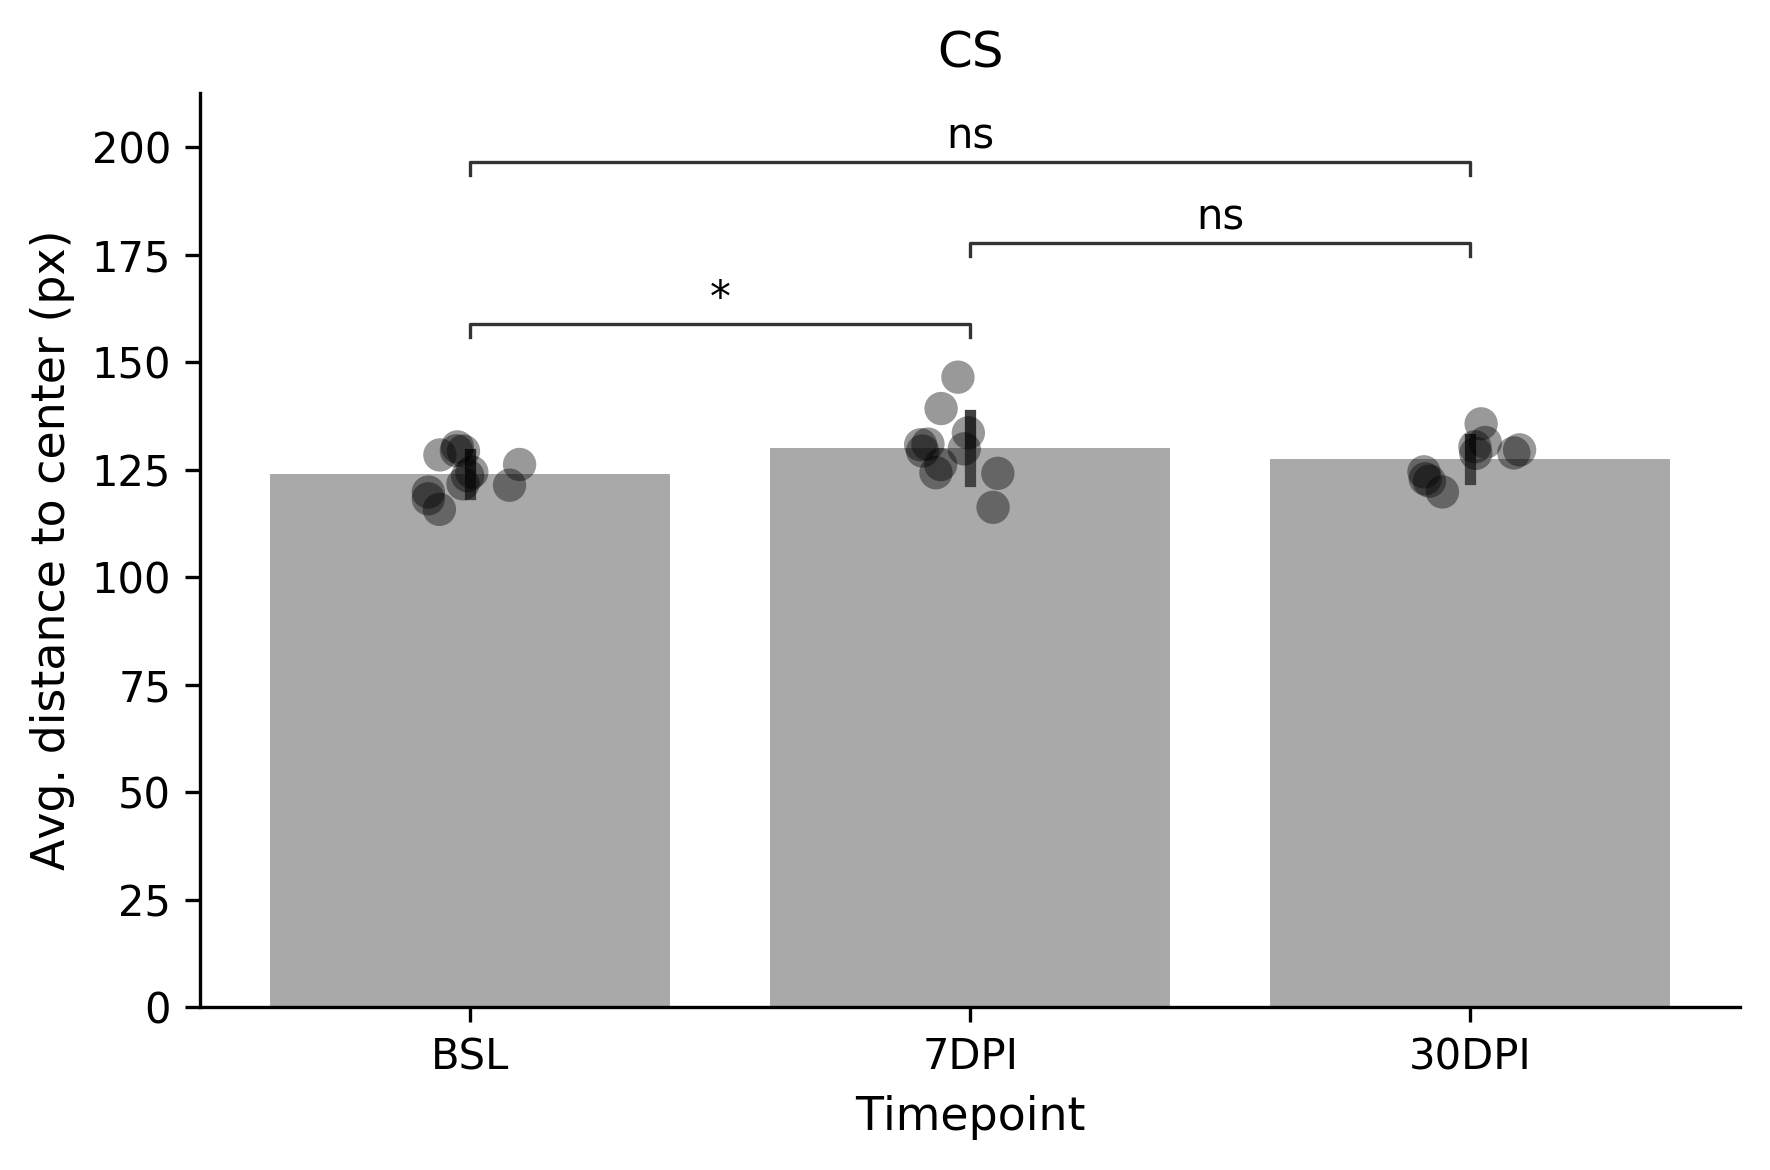

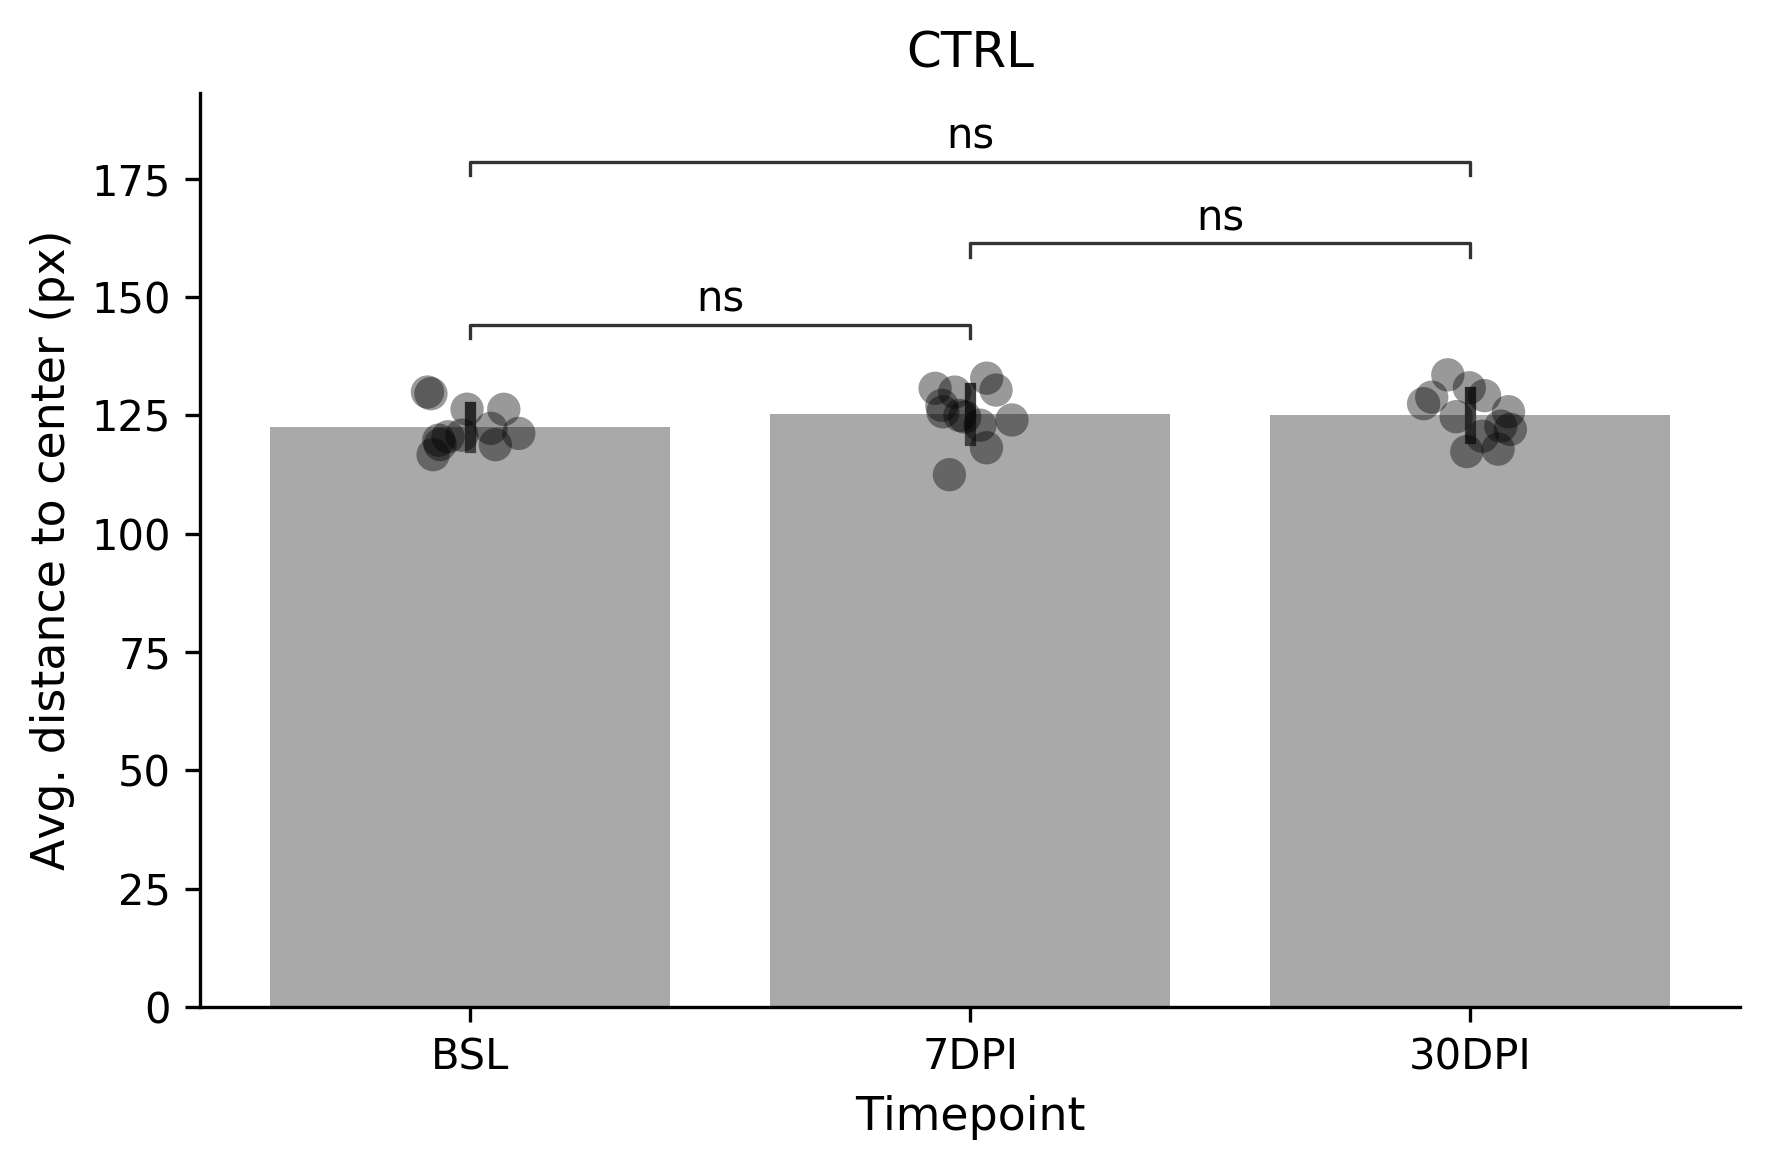

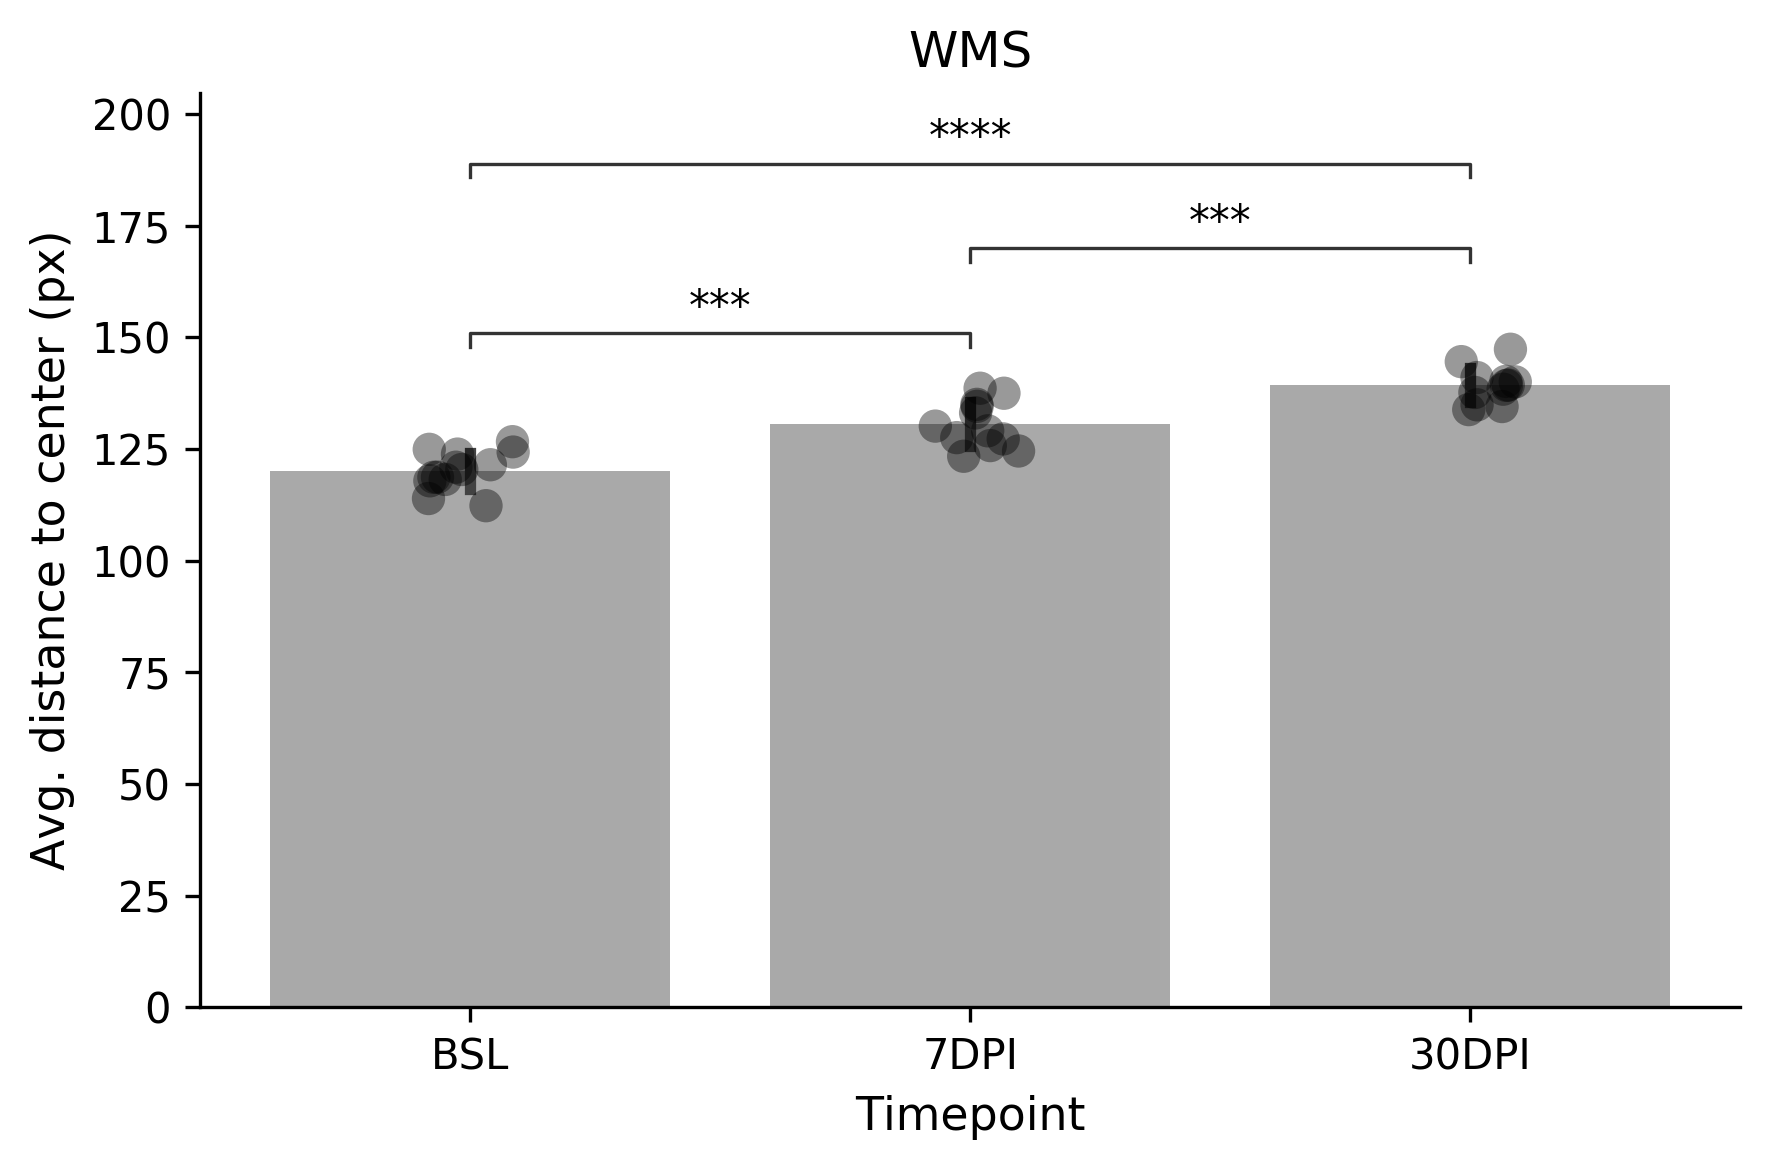

In [ ]:
for treatment, subset in oft.groupby('treatment'):
    subset = subset.copy()
    present = subset['timepoint'].unique().tolist()
    pairs = [p for p in combinations(timepoint_order, 2) if p[0] in present and p[1] in present]

    fig, ax = plt.subplots()
    fig.dpi = 300

    sns.barplot(
        data=subset,
        x='timepoint',
        y='avg_dist_to_center_px',
        order=timepoint_order,
        color='darkgray',
        ci='sd',
        ax=ax,
    )
    sns.stripplot(
        data=subset,
        x='timepoint',
        y='avg_dist_to_center_px',
        order=timepoint_order,
        color='black',
        size=8,
        jitter=True,
        alpha=0.4,
        ax=ax,
        zorder=3,
    )

    try:
        annotator = Annotator(
            ax, pairs,
            data=subset,
            x='timepoint',
            y='avg_dist_to_center_px',
            order=timepoint_order,
        )
        annotator.configure(
            test='Mann-Whitney',
            text_format='star',
            loc='inside',
            verbose=0,
            comparisons_correction=None,
            line_width=0.8,
            fontsize=10,
        )
        annotator.apply_and_annotate()
    except ValueError as e:
        print(f"Skipping annotation for {treatment}: {e}")

    ax.set_title(treatment)
    ax.set_xlabel('Timepoint', fontsize=11)
    ax.set_ylabel('Avg. distance to center (px)', fontsize=11)
    ax.set_ylim(bottom=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=10)
    plt.tight_layout()
    plt.savefig(SAVE_PATH / f'Open_Field_Results_{treatment}.pdf')
    plt.show()